#  PRÁCTICA MACHINE LEARNING: PREDICCIÓN DEL MERCADO DE VALORES
##  PARTE 1: EXPLORACIÓN Y PREPROCESAMIENTO DEL DATASET 

### 1.1 Instalación de Dependencias y Configuración Inicial

In [48]:
# Instalar dependencias necesarias
import sys
!{sys.executable} -m pip install -q --upgrade numerapi pandas pyarrow matplotlib lightgbm scikit-learn scipy cloudpickle==3.1.1
!{sys.executable} -m pip install -q --no-deps numerai-tools

# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from numerapi import NumerAPI
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import lightgbm as lgb
import cloudpickle
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("="*80)

### 1.2 Descarga y Carga del Dataset

In [49]:
print("="*80)
print("DESCARGA Y CARGA DEL DATASET")
print("="*80)

# Inicializar NumerAPI
napi = NumerAPI()
DATA_VERSION = "v5.0"

# Listar archivos disponibles
print("\n📁 Archivos disponibles:")
available_files = [f for f in napi.list_datasets() if f.startswith(DATA_VERSION)]
for f in available_files[:10]: 
    print(f"   • {f}")

# Descargar datos de entrenamiento y metadatos
print("\n⏳ Descargando datos de entrenamiento y metadatos...")
print("   (Esto puede tomar varios minutos ☕)")

try:
    napi.download_dataset(f"{DATA_VERSION}/train.parquet")
    napi.download_dataset(f"{DATA_VERSION}/features.json")
    print("✅ Descarga completada")
except Exception as e:
    print(f"⚠️ Error en descarga: {e}")
    print("   Los archivos pueden ya estar descargados localmente")

# Cargar metadatos de características
feature_metadata = json.load(open(f"{DATA_VERSION}/features.json"))
feature_sets = feature_metadata["feature_sets"]

print("\n📊 Conjuntos de características disponibles:")
for feature_set_name in ["small", "medium", "all"]:
    print(f"   • {feature_set_name}: {len(feature_sets[feature_set_name])} características")

# Usaremos el conjunto "medium" para balance entre rendimiento y precisión
feature_set = feature_sets["medium"]
print(f"\n✓ Seleccionado: conjunto 'medium' con {len(feature_set)} características")

# Cargar datos de entrenamiento
print("\n⏳ Cargando datos de entrenamiento...")
train = pd.read_parquet(
    f"{DATA_VERSION}/train.parquet",
    columns=["era", "target"] + feature_set
)

print(f"\n✅ DATOS CARGADOS:")
print(f"   • Dimensiones: {train.shape[0]:,} filas × {train.shape[1]} columnas")
print(f"   • Características: {len(feature_set)}")
print(f"   • Eras únicas: {train['era'].nunique()}")
print(f"   • Memoria: {train.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n🔍 Primeras filas:")
display(train.head())

print("="*80)

DESCARGA Y CARGA DEL DATASET

📁 Archivos disponibles:
   • v5.0/features.json
   • v5.0/live.parquet
   • v5.0/live_benchmark_models.parquet
   • v5.0/live_example_preds.csv
   • v5.0/live_example_preds.parquet
   • v5.0/meta_model.parquet
   • v5.0/train.parquet
   • v5.0/train_benchmark_models.parquet
   • v5.0/validation.parquet
   • v5.0/validation_benchmark_models.parquet

⏳ Descargando datos de entrenamiento y metadatos...
   (Esto puede tomar varios minutos ☕)


2025-11-04 19:05:25,767 INFO numerapi.utils: target file already exists
2025-11-04 19:05:25,768 INFO numerapi.utils: download complete
2025-11-04 19:05:27,146 INFO numerapi.utils: target file already exists
2025-11-04 19:05:27,147 INFO numerapi.utils: download complete


✅ Descarga completada

📊 Conjuntos de características disponibles:
   • small: 42 características
   • medium: 705 características
   • all: 2376 características

✓ Seleccionado: conjunto 'medium' con 705 características

⏳ Cargando datos de entrenamiento...

✅ DATOS CARGADOS:
   • Dimensiones: 2,746,270 filas × 707 columnas
   • Características: 705
   • Eras únicas: 574
   • Memoria: 2207.86 MB

🔍 Primeras filas:


,era,target,feature_able_deprived_nona,feature_ablest_inflexional_egeria,feature_absorbable_hyperalgesic_mode,feature_accoutered_revolute_vexillology,feature_acetose_crackerjack_needlecraft,feature_acheulian_conserving_output,feature_acronychal_bilobate_stevenage,feature_acrylic_gallic_wine,...,feature_working_jain_acromegaly,feature_wrapround_chrestomathic_timarau,feature_xanthic_transpadane_saleswoman,feature_xanthochroid_petrified_gutenberg,feature_zincy_cirrhotic_josh,feature_zippy_trine_diffraction,feature_zonal_snuffly_chemism,feature_zygotic_middlebrow_caribbean,feature_zymolytic_intertidal_privet,feature_zymotic_windswept_cooky
id,,,,,,,,,,,,,,,,,,,,,
n0007b5abb0c3a25,0001,0.25,1,2,3,2,3,2,2,2,...,2,0,3,2,4,3,2,1,0,0
n003bba8a98662e4,0001,0.25,3,2,4,1,0,2,3,2,...,2,0,0,2,0,0,2,0,0,0
n003bee128c2fcfc,0001,0.75,1,2,0,2,4,2,0,2,...,2,3,3,2,2,3,2,2,2,4
n0048ac83aff7194,0001,0.25,1,2,3,4,0,2,3,2,...,2,0,2,1,1,4,2,0,2,1
n0055a2401ba6480,0001,0.25,3,2,3,4,1,2,4,2,...,2,1,3,3,2,4,2,4,1,3


### 1.3 Exploración Inicial del Dataset

**Contexto del Dataset:**
- Cada fila representa una **acción (stock)** en un momento específico
- **"era"**: Identificador temporal (cada era = 1 semana)
- **"target"**: Medida de rendimientos a 20 días (valores: 0, 0.25, 0.5, 0.75, 1.0)
- **Features**: Atributos cuantitativos ofuscados (fundamentos, señales técnicas, datos de mercado)
- Los valores están **agrupados en bins** para prevenir overfitting

In [50]:
print("="*80)
print("EXPLORACIÓN INICIAL DEL DATASET")
print("="*80)

# A) Información básica
print("\n📊 INFORMACIÓN BÁSICA:")
print(f"   • Total de filas: {train.shape[0]:,}")
print(f"   • Total de columnas: {train.shape[1]}")
print(f"   • Eras únicas: {train['era'].nunique()}")
print(f"   • Rango de eras: {train['era'].min()} - {train['era'].max()}")

# B) Valores nulos
print(f"\n⚠️ VALORES NULOS:")
null_counts = train.isnull().sum()
if null_counts.sum() == 0:
    print("   ✅ No hay valores nulos en el dataset")
else:
    print(f"   Total de valores nulos: {null_counts.sum()}")
    print(null_counts[null_counts > 0])

# C) Tipos de datos
print(f"\n📋 TIPOS DE DATOS:")
print(f"   • era: {train['era'].dtype}")
print(f"   • target: {train['target'].dtype}")
print(f"   • features: {train[feature_set[0]].dtype} (todas numéricas)")

# D) Estadísticas descriptivas del target
print(f"\n📈 ESTADÍSTICAS DEL TARGET:")
print(train['target'].describe())

# E) Distribución de valores únicos del target
print(f"\n📊 DISTRIBUCIÓN DEL TARGET:")
target_counts = train['target'].value_counts().sort_index()
print(target_counts)
print(f"\n   Valores únicos esperados: [0, 0.25, 0.5, 0.75, 1.0]")
print(f"   Valores únicos encontrados: {sorted(train['target'].unique())}")

print("="*80)

EXPLORACIÓN INICIAL DEL DATASET

📊 INFORMACIÓN BÁSICA:
   • Total de filas: 2,746,270
   • Total de columnas: 707
   • Eras únicas: 574
   • Rango de eras: 0001 - 0574

⚠️ VALORES NULOS:
   ✅ No hay valores nulos en el dataset

📋 TIPOS DE DATOS:
   • era: object
   • target: float32
   • features: int8 (todas numéricas)

📈 ESTADÍSTICAS DEL TARGET:
count    2.746270e+06
mean     5.000268e-01
std      2.231753e-01
min      0.000000e+00
25%      2.500000e-01
50%      5.000000e-01
75%      5.000000e-01
max      1.000000e+00
Name: target, dtype: float64

📊 DISTRIBUCIÓN DEL TARGET:
target
0.00     135668
0.25     550995
0.50    1373108
0.75     550373
1.00     136126
Name: count, dtype: int64

   Valores únicos esperados: [0, 0.25, 0.5, 0.75, 1.0]
   Valores únicos encontrados: [np.float32(0.0), np.float32(0.25), np.float32(0.5), np.float32(0.75), np.float32(1.0)]


### 1.4 Visualización Exploratoria

**Gráficas importantes para entender el dataset:**
1. **Filas por era**: Verifica consistencia temporal del dataset
2. **Distribución del target**: Comprueba el balance de valores objetivo
3. **Distribución de features**: Analiza la normalización en bins
4. **Correlación con target**: Identifica features potencialmente útiles

GRÁFICA 1: FILAS POR ERA

💡 IMPORTANCIA:
   Esta gráfica muestra cuántas acciones (stocks) están disponibles en cada era.
   Es crucial para detectar:
   • Cambios en el universo de inversión
   • Inconsistencias temporales
   • Períodos con datos faltantes


2025-11-04 19:05:35,081 INFO matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-11-04 19:05:35,084 INFO matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-11-04 19:05:35,090 INFO matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


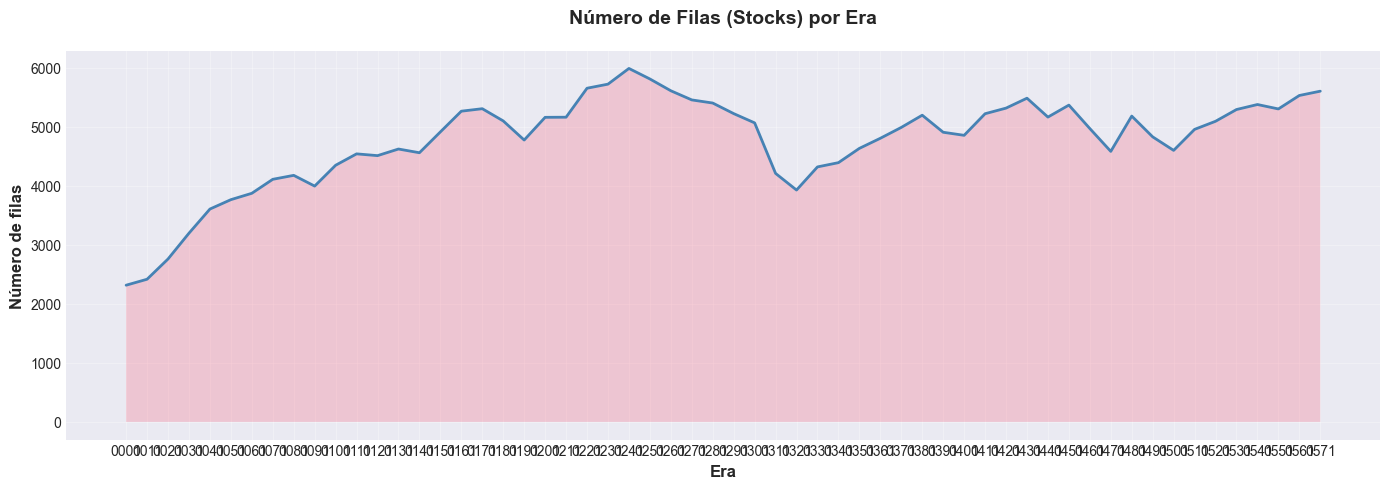


📊 ANÁLISIS:
   • Media de stocks por era: 4784
   • Desviación estándar: 753
   • Rango: [2316, 6009]


In [51]:
# A) Número de filas por era - IMPORTANTE: muestra la consistencia temporal
print("="*80)
print("GRÁFICA 1: FILAS POR ERA")
print("="*80)
print("\n💡 IMPORTANCIA:")
print("   Esta gráfica muestra cuántas acciones (stocks) están disponibles en cada era.")
print("   Es crucial para detectar:")
print("   • Cambios en el universo de inversión")
print("   • Inconsistencias temporales")
print("   • Períodos con datos faltantes")

plt.figure(figsize=(14, 5))
era_counts = train.groupby("era").size()
plt.plot(era_counts.index[::10], era_counts.values[::10], linewidth=2, color='steelblue')
plt.fill_between(era_counts.index[::10], era_counts.values[::10], alpha=0.3)
plt.xlabel('Era', fontsize=12, fontweight='bold')
plt.ylabel('Número de filas', fontsize=12, fontweight='bold')
plt.title('Número de Filas (Stocks) por Era', fontsize=14, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n📊 ANÁLISIS:")
print(f"   • Media de stocks por era: {era_counts.mean():.0f}")
print(f"   • Desviación estándar: {era_counts.std():.0f}")
print(f"   • Rango: [{era_counts.min()}, {era_counts.max()}]")

print("="*80)

GRÁFICA 2: DISTRIBUCIÓN DEL TARGET

💡 IMPORTANCIA:
   El target representa rendimientos futuros de acciones (20 días adelante).
   Los valores están en bins desiguales: 0, 0.25, 0.5, 0.75, 1.0
   Es esencial verificar:
   • Balance entre clases
   • Si hay suficientes ejemplos en cada bin


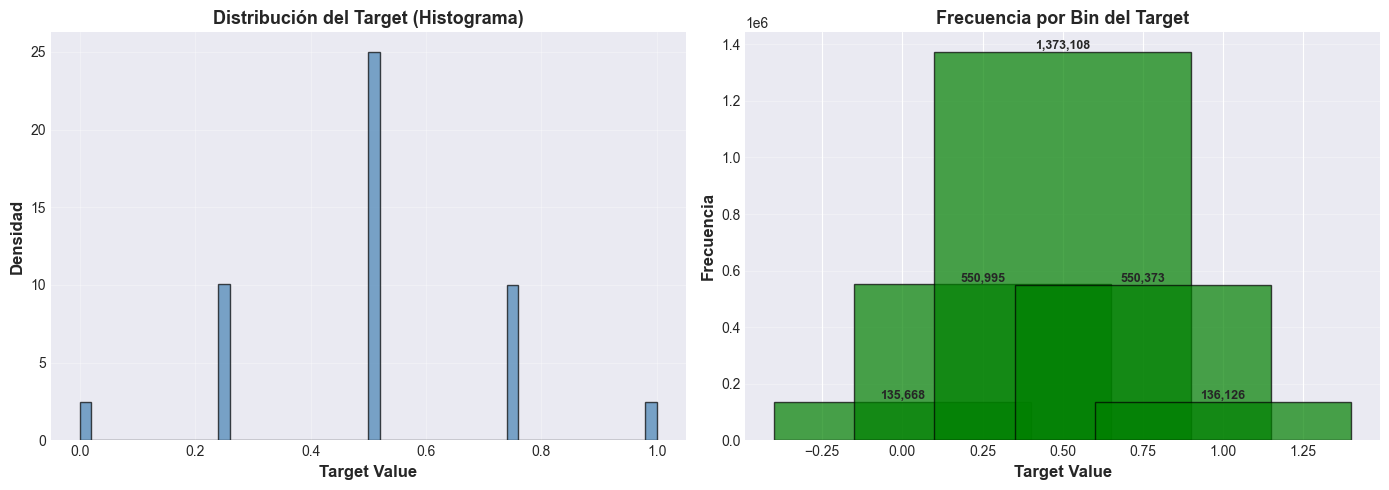


📊 ANÁLISIS:
   • Target = 0.0: 135,668 (4.94%)
   • Target = 0.25: 550,995 (20.06%)
   • Target = 0.5: 1,373,108 (50.00%)
   • Target = 0.75: 550,373 (20.04%)
   • Target = 1.0: 136,126 (4.96%)


In [52]:
# B) Distribución del target - CRÍTICO para entender el problema
print("="*80)
print("GRÁFICA 2: DISTRIBUCIÓN DEL TARGET")
print("="*80)
print("\n💡 IMPORTANCIA:")
print("   El target representa rendimientos futuros de acciones (20 días adelante).")
print("   Los valores están en bins desiguales: 0, 0.25, 0.5, 0.75, 1.0")
print("   Es esencial verificar:")
print("   • Balance entre clases")
print("   • Si hay suficientes ejemplos en cada bin")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
train['target'].plot(kind='hist', bins=50, density=True, ax=ax1, 
                     color='steelblue', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Target Value', fontsize=12, fontweight='bold')
ax1.set_ylabel('Densidad', fontsize=12, fontweight='bold')
ax1.set_title('Distribución del Target (Histograma)', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Countplot
target_counts = train['target'].value_counts().sort_index()
ax2.bar(target_counts.index, target_counts.values, color='green', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Target Value', fontsize=12, fontweight='bold')
ax2.set_ylabel('Frecuencia', fontsize=12, fontweight='bold')
ax2.set_title('Frecuencia por Bin del Target', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
for i, (idx, val) in enumerate(target_counts.items()):
    ax2.text(idx, val, f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n📊 ANÁLISIS:")
for val, count in target_counts.items():
    pct = count / len(train) * 100
    print(f"   • Target = {val}: {count:,} ({pct:.2f}%)")

print("="*80)

GRÁFICA 3: DISTRIBUCIÓN DE FEATURES SELECCIONADAS

💡 IMPORTANCIA:
   Las features están normalizadas en 5 bins (0, 1, 2, 3, 4).
   Cuando faltan datos, todos los valores se establecen en 2.
   Esta gráfica ayuda a:
   • Verificar la normalización correcta
   • Detectar features con datos faltantes (pico en 2)
   • Identificar features con distribuciones anómalas


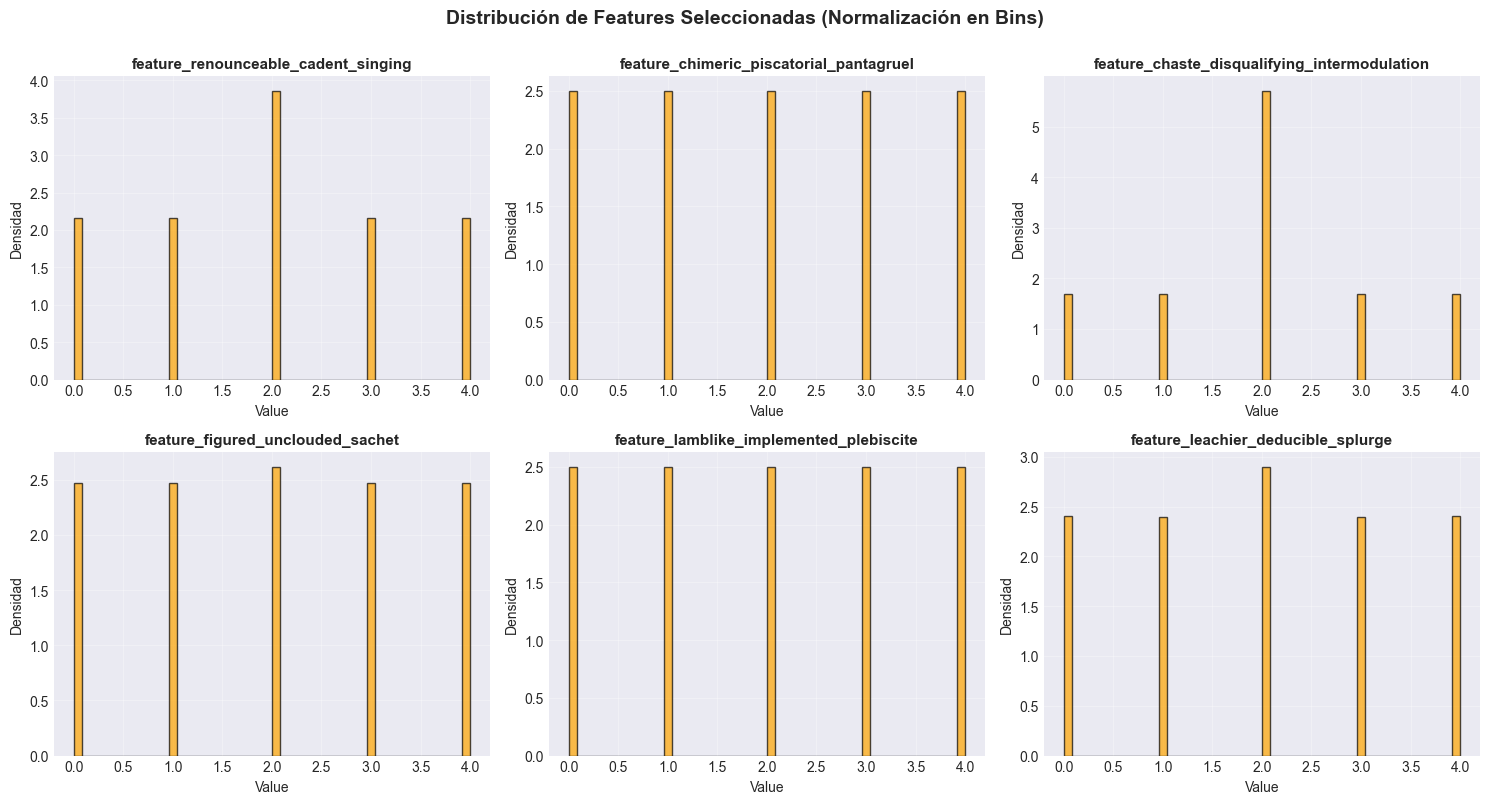


📊 ANÁLISIS DE FEATURES:
   • Total de features: 705
   • Valores esperados por feature: [0, 1, 2, 3, 4]
   • Si hay pico en 2 → Indica datos faltantes en esas eras


In [53]:
# C) Distribución de features - Verificar normalización en bins
print("="*80)
print("GRÁFICA 3: DISTRIBUCIÓN DE FEATURES SELECCIONADAS")
print("="*80)
print("\n💡 IMPORTANCIA:")
print("   Las features están normalizadas en 5 bins (0, 1, 2, 3, 4).")
print("   Cuando faltan datos, todos los valores se establecen en 2.")
print("   Esta gráfica ayuda a:")
print("   • Verificar la normalización correcta")
print("   • Detectar features con datos faltantes (pico en 2)")
print("   • Identificar features con distribuciones anómalas")

# Seleccionar algunas features aleatorias para visualizar
np.random.seed(42)
sample_features = np.random.choice(feature_set, size=min(6, len(feature_set)), replace=False)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, feat in enumerate(sample_features):
    train[feat].plot(kind='hist', bins=50, density=True, ax=axes[idx],
                     color='orange', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{feat}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Value', fontsize=10)
    axes[idx].set_ylabel('Densidad', fontsize=10)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Distribución de Features Seleccionadas (Normalización en Bins)', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print(f"\n📊 ANÁLISIS DE FEATURES:")
print(f"   • Total de features: {len(feature_set)}")
print(f"   • Valores esperados por feature: [0, 1, 2, 3, 4]")
print(f"   • Si hay pico en 2 → Indica datos faltantes en esas eras")

print("="*80)

GRÁFICA 4: CORRELACIÓN DE FEATURES CON TARGET

💡 IMPORTANCIA:
   Muestra qué features tienen mayor correlación con el target.
   Aunque las correlaciones serán bajas (mercados = ruidosos),
   las features con mayor correlación absoluta son las más útiles.

 Calculando correlaciones...


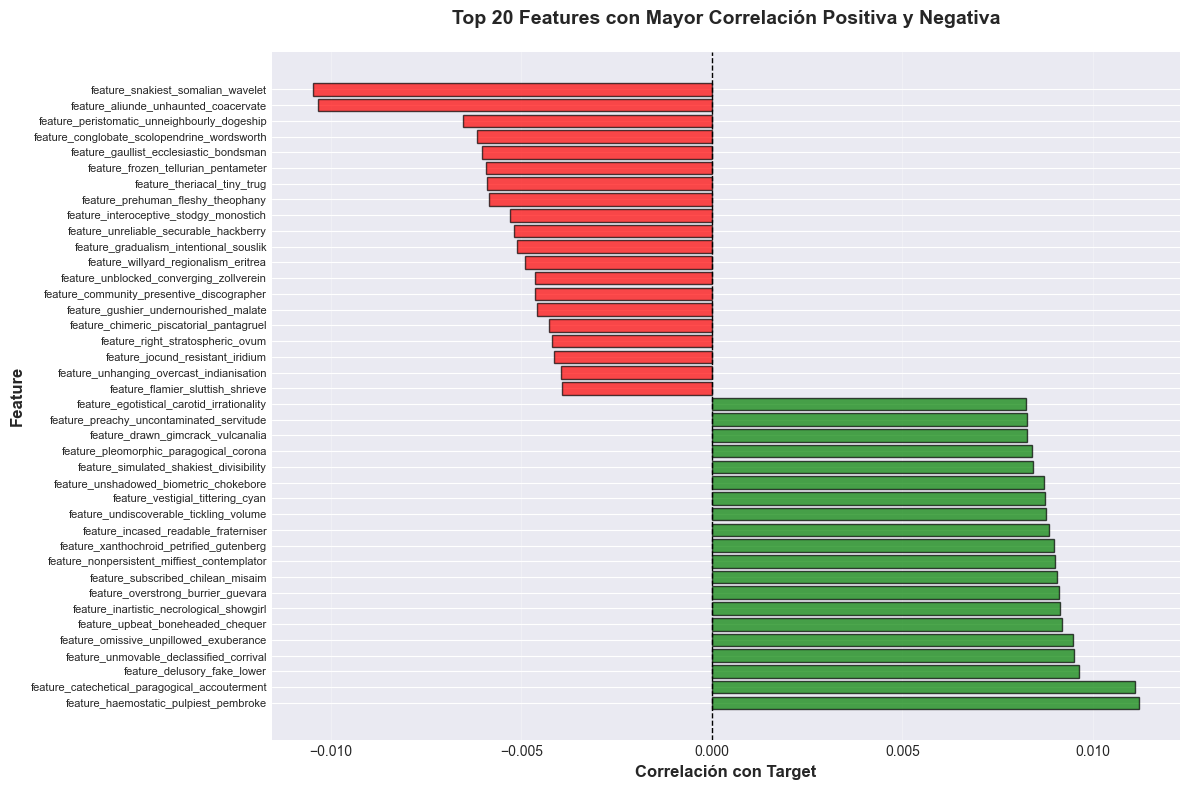


📊 TOP 10 FEATURES CON MAYOR CORRELACIÓN ABSOLUTA:
    1. feature_haemostatic_pulpiest_pembroke: +0.011209 (|0.011209|)
    2. feature_catechetical_paragogical_accouterment: +0.011118 (|0.011118|)
    3. feature_snakiest_somalian_wavelet: -0.010464 (|0.010464|)
    4. feature_aliunde_unhaunted_coacervate: -0.010334 (|0.010334|)
    5. feature_delusory_fake_lower: +0.009643 (|0.009643|)
    6. feature_unmovable_declassified_corrival: +0.009509 (|0.009509|)
    7. feature_omissive_unpillowed_exuberance: +0.009481 (|0.009481|)
    8. feature_upbeat_boneheaded_chequer: +0.009194 (|0.009194|)
    9. feature_inartistic_necrological_showgirl: +0.009149 (|0.009149|)
   10. feature_overstrong_burrier_guevara: +0.009128 (|0.009128|)

  Las correlaciones son muy bajas (típico en finanzas)
   • Rango: [-0.010464, 0.011209]
   • Esto es NORMAL en mercados financieros (alta incertidumbre)


In [54]:
# D) Correlación de features con target - Identificar features relevantes
print("="*80)
print("GRÁFICA 4: CORRELACIÓN DE FEATURES CON TARGET")
print("="*80)
print("\n💡 IMPORTANCIA:")
print("   Muestra qué features tienen mayor correlación con el target.")
print("   Aunque las correlaciones serán bajas (mercados = ruidosos),")
print("   las features con mayor correlación absoluta son las más útiles.")

# Calcular correlaciones
print("\n Calculando correlaciones...")
correlations = train[feature_set].corrwith(train['target']).sort_values(ascending=False)

# Visualizar top 20 positivas y top 20 negativas
top_corr = pd.concat([correlations.head(20), correlations.tail(20)])

plt.figure(figsize=(12, 8))
colors = ['green' if x > 0 else 'red' for x in top_corr.values]
plt.barh(range(len(top_corr)), top_corr.values, color=colors, edgecolor='black', alpha=0.7)
plt.yticks(range(len(top_corr)), top_corr.index, fontsize=8)
plt.xlabel('Correlación con Target', fontsize=12, fontweight='bold')
plt.ylabel('Feature', fontsize=12, fontweight='bold')
plt.title('Top 20 Features con Mayor Correlación Positiva y Negativa', 
          fontsize=14, fontweight='bold', pad=20)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print(f"\n📊 TOP 10 FEATURES CON MAYOR CORRELACIÓN ABSOLUTA:")
abs_corr = correlations.abs().sort_values(ascending=False)
for i, (feat, corr_val) in enumerate(abs_corr.head(10).items(), 1):
    original_corr = correlations[feat]
    print(f"   {i:2d}. {feat}: {original_corr:+.6f} (|{corr_val:.6f}|)")

print(f"\n  Las correlaciones son muy bajas (típico en finanzas)")
print(f"   • Rango: [{correlations.min():.6f}, {correlations.max():.6f}]")
print(f"   • Esto es NORMAL en mercados financieros (alta incertidumbre)")

print("="*80)

### 1.5 Reducción del Dataset (Justificación)

**¿Por qué reducir el dataset?**
- El dataset completo tiene millones de filas (lo hace demasiado pesado en terminos de computacion)
- Para experimentación rápida, es mejor usar un subset representativo
- Tomaremos cada 2da era para mantener buena cobertura temporal

**Estrategia de reducción:**
1. Muestrear cada 2 eras (eras 0001, 0003, 0005, 0007, ...)
2. Mantiene mejor representación temporal que cada 4 eras
3. Reduce ~50% del tamaño
4. Balance óptimo entre precisión y tiempo de entrenamiento
5. Más datos para aprender patrones → mejor generalización

In [55]:
print("="*80)
print("REDUCCIÓN DEL DATASET")
print("="*80)

print(f"\n📊 ANTES DE LA REDUCCIÓN:")
print(f"   • Total de filas: {train.shape[0]:,}")
print(f"   • Total de eras: {train['era'].nunique()}")
print(f"   • Memoria: {train.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Reducir tomando cada 2da era (mejor balance que cada 4)
train_reduced = train[train["era"].isin(train["era"].unique()[::2])].copy()

print(f"\n✅ DESPUÉS DE LA REDUCCIÓN (cada 2da era):")
print(f"   • Total de filas: {train_reduced.shape[0]:,}")
print(f"   • Total de eras: {train_reduced['era'].nunique()}")
print(f"   • Memoria: {train_reduced.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"   • Reducción: {(1 - train_reduced.shape[0]/train.shape[0])*100:.1f}%")

print(f"\n💡 JUSTIFICACIÓN:")
print(f"   ✓ Reduce 50% del dataset (vs 75% con cada 4 eras)")
print(f"   ✓ MÁS DATOS para entrenar → mejor generalización")
print(f"   ✓ Mejor cobertura temporal → menos saltos entre períodos")
print(f"   ✓ Mantiene representación uniforme del mercado")
print(f"   ✓ Balance óptimo: precisión mejorada sin sobrecarga excesiva")

# Verificar que se mantiene la distribución del target
print(f"\n📊 VERIFICACIÓN - Distribución del target:")
print(f"   Original:")
for val, pct in (train['target'].value_counts(normalize=True).sort_index() * 100).items():
    print(f"      {val}: {pct:.2f}%")
print(f"   Reducido:")
for val, pct in (train_reduced['target'].value_counts(normalize=True).sort_index() * 100).items():
    print(f"      {val}: {pct:.2f}%")

# Usar el dataset reducido de aquí en adelante
train = train_reduced
del train_reduced

print("="*80)

REDUCCIÓN DEL DATASET

📊 ANTES DE LA REDUCCIÓN:
   • Total de filas: 2,746,270
   • Total de eras: 574
   • Memoria: 2272.36 MB

✅ DESPUÉS DE LA REDUCCIÓN (cada 2da era):
   • Total de filas: 1,372,218
   • Total de eras: 287
   • Memoria: 1103.19 MB
   • Reducción: 50.0%

💡 JUSTIFICACIÓN:
   ✓ Reduce 50% del dataset (vs 75% con cada 4 eras)
   ✓ MÁS DATOS para entrenar → mejor generalización
   ✓ Mejor cobertura temporal → menos saltos entre períodos
   ✓ Mantiene representación uniforme del mercado
   ✓ Balance óptimo: precisión mejorada sin sobrecarga excesiva

📊 VERIFICACIÓN - Distribución del target:
   Original:
      0.0: 4.94%
      0.25: 20.06%
      0.5: 50.00%
      0.75: 20.04%
      1.0: 4.96%
   Reducido:
      0.0: 4.93%
      0.25: 20.07%
      0.5: 50.00%
      0.75: 20.04%
      1.0: 4.95%


### 1.6 Selección de Características (Feature Selection)

**¿Por qué eliminar características poco relevantes?**
- Reduce dimensionalidad → menos riesgo de overfitting
- Acelera entrenamiento
- Mejora interpretabilidad
- Elimina ruido

**Métodos a usar:**
1. **Correlación con target**: Eliminar features con correlación muy baja
2. **Varianza**: Eliminar features con varianza casi nula
3. **Random Forest Feature Importance**: Usar modelo base para identificar features útiles

In [56]:
print("="*80)
print("SELECCIÓN DE CARACTERÍSTICAS")
print("="*80)

# MÉTODO 1: Filtrar por correlación con target
print("\n📊 MÉTODO 1: CORRELACIÓN CON TARGET")
print("   Eliminamos features con correlación absoluta muy baja (< 0.002)")

correlations = train[feature_set].corrwith(train['target']).abs()
threshold_corr = 0.002
selected_by_corr = correlations[correlations >= threshold_corr].index.tolist()

print(f"   • Features originales: {len(feature_set)}")
print(f"   • Features con |corr| >= {threshold_corr}: {len(selected_by_corr)}")
print(f"   • Eliminadas: {len(feature_set) - len(selected_by_corr)}")

# MÉTODO 2: Filtrar por varianza
print("\n📊 MÉTODO 2: VARIANZA")
print("   Eliminamos features con varianza muy baja (casi constantes)")

variances = train[feature_set].var()
threshold_var = 0.5
selected_by_var = variances[variances >= threshold_var].index.tolist()

print(f"   • Features con varianza >= {threshold_var}: {len(selected_by_var)}")
print(f"   • Eliminadas: {len(feature_set) - len(selected_by_var)}")

# MÉTODO 3: Random Forest Feature Importance
print("\n📊 MÉTODO 3: RANDOM FOREST FEATURE IMPORTANCE")
print("   Entrenaremos un RF rápido para identificar features importantes")

# Tomar muestra pequeña para entrenar rápido
sample_size = min(50000, len(train))
train_sample = train.sample(n=sample_size, random_state=42)

print(f"   • Entrenando RF con muestra de {sample_size:,} filas...")

# Utilizare un random forest con parámetros ajustados para obtener correlaciones y poder eliminar features irrelevantes
rf_selector = RandomForestRegressor(
    n_estimators=300,         
    max_depth=10,             
    min_samples_split=5,      
    min_samples_leaf=2,       
    max_features='sqrt',      
    random_state=42,
    n_jobs=-1,
    verbose=1                
)

rf_selector.fit(train_sample[feature_set], train_sample['target'])

# Obtener importancias
feature_importances = pd.Series(
    rf_selector.feature_importances_,
    index=feature_set
).sort_values(ascending=False)

# Seleccionar top features por importancia
top_n_features = 100  # Nos quedamos con las top 100
selected_by_importance = feature_importances.head(top_n_features).index.tolist()

print(f"   • Seleccionadas top {top_n_features} features por importancia")

# COMBINACIÓN: Intersección de los 3 métodos
selected_features = list(set(selected_by_corr) & set(selected_by_var) & set(selected_by_importance))

print(f"\n✅ RESULTADO FINAL (Intersección de 3 métodos):")
print(f"   • Features seleccionadas: {len(selected_features)}")
print(f"   • Features eliminadas: {len(feature_set) - len(selected_features)}")
print(f"   • Reducción: {(1 - len(selected_features)/len(feature_set))*100:.1f}%")

print(f"\n💡 JUSTIFICACIÓN:")
print(f"   ✓ Correlación: Elimina features sin relación con target")
print(f"   ✓ Varianza: Elimina features casi constantes (sin información)")
print(f"   ✓ RF Importance: Identifica features útiles para predicción")
print(f"   ✓ Intersección: Asegura que las features pasen los 3 criterios")

print("="*80)

SELECCIÓN DE CARACTERÍSTICAS

📊 MÉTODO 1: CORRELACIÓN CON TARGET
   Eliminamos features con correlación absoluta muy baja (< 0.002)
   • Features originales: 705
   • Features con |corr| >= 0.002: 313
   • Eliminadas: 392

📊 MÉTODO 2: VARIANZA
   Eliminamos features con varianza muy baja (casi constantes)
   • Features con varianza >= 0.5: 705
   • Eliminadas: 0

📊 MÉTODO 3: RANDOM FOREST FEATURE IMPORTANCE
   Entrenaremos un RF rápido para identificar features importantes
   • Entrenando RF con muestra de 50,000 filas...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    3.6s


   • Seleccionadas top 100 features por importancia

✅ RESULTADO FINAL (Intersección de 3 métodos):
   • Features seleccionadas: 47
   • Features eliminadas: 658
   • Reducción: 93.3%

💡 JUSTIFICACIÓN:
   ✓ Correlación: Elimina features sin relación con target
   ✓ Varianza: Elimina features casi constantes (sin información)
   ✓ RF Importance: Identifica features útiles para predicción
   ✓ Intersección: Asegura que las features pasen los 3 criterios


[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:    6.1s finished


### 1.7 Aplicación de PCA (Análisis de Componentes Principales)

**¿Por qué aplicar PCA?**
- Reduce dimensionalidad manteniendo varianza
- Elimina multicolinealidad entre features
- Transforma features correlacionadas en componentes independientes
- Puede mejorar generalización del modelo

**Proceso:**
1. Estandarizar features (requisito de PCA)
2. Aplicar PCA y analizar varianza explicada
3. Determinar número óptimo de componentes (ej: 95% varianza)
4. Evaluar si mejora el rendimiento

APLICACIÓN DE PCA

📊 DATOS ANTES DE PCA:
   • Dimensiones X: (1372218, 47)
   • Features: 47

📊 PASO 1: ESTANDARIZACIÓN
   Usamos StandardScaler para normalizar features
   ✓ Media después de escalado: 0.000000
   ✓ Desviación estándar: 1.000000

📊 PASO 2: ANÁLISIS DE VARIANZA EXPLICADA

   Componentes necesarios para:
   • 90% de varianza: 30 componentes
   • 95% de varianza: 34 componentes
   • 99% de varianza: 39 componentes


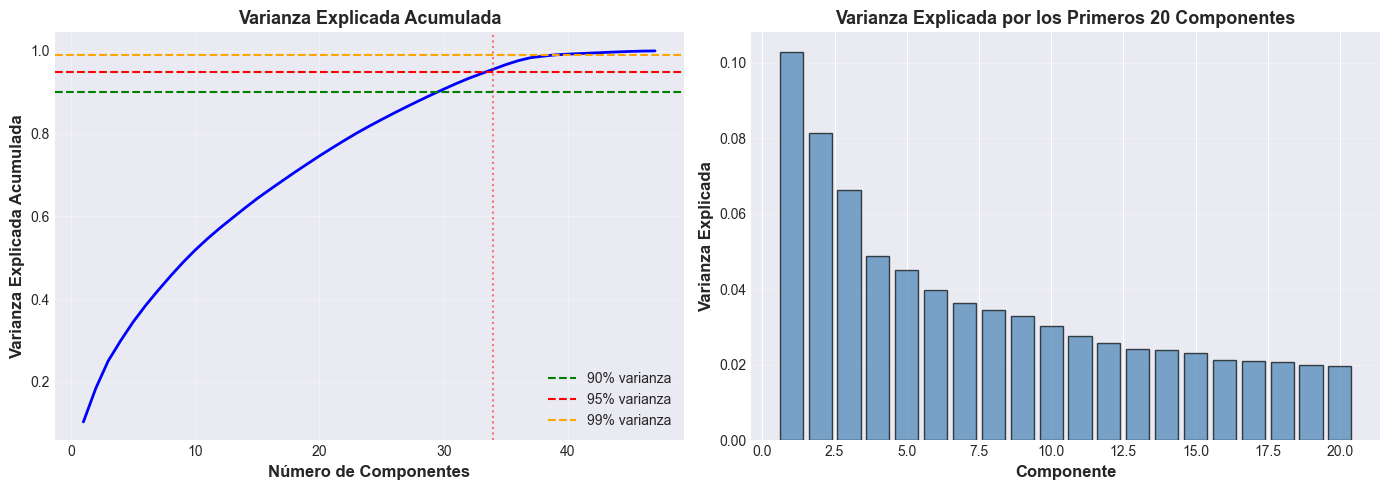


✅ DECISIÓN: Usar 34 componentes (95% varianza)

💡 JUSTIFICACIÓN:
   • Original: 47 features
   • Con PCA: 34 componentes
   • Reducción: 27.7%
   • Varianza preservada: 95.59%
   • Balance óptimo: Reduce dimensionalidad manteniendo información

📊 PASO 3: TRANSFORMACIÓN CON PCA
   ✓ Datos transformados con PCA
   • Shape original: (1372218, 47)
   • Shape con PCA: (1372218, 34)


In [57]:
print("="*80)
print("APLICACIÓN DE PCA")
print("="*80)

# Preparar datos: separar X e y
X_full = train[selected_features].copy()
y_full = train['target'].copy()

print(f"\n📊 DATOS ANTES DE PCA:")
print(f"   • Dimensiones X: {X_full.shape}")
print(f"   • Features: {len(selected_features)}")

# PASO 1: Estandarización (requisito para PCA)
print(f"\n📊 PASO 1: ESTANDARIZACIÓN")
print(f"   Usamos StandardScaler para normalizar features")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

print(f"   ✓ Media después de escalado: {X_scaled.mean():.6f}")
print(f"   ✓ Desviación estándar: {X_scaled.std():.6f}")

# PASO 2: Aplicar PCA completo para analizar varianza
print(f"\n📊 PASO 2: ANÁLISIS DE VARIANZA EXPLICADA")

pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Encontrar número de componentes para diferentes umbrales
n_comp_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_comp_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_comp_99 = np.argmax(cumulative_variance >= 0.99) + 1

print(f"\n   Componentes necesarios para:")
print(f"   • 90% de varianza: {n_comp_90} componentes")
print(f"   • 95% de varianza: {n_comp_95} componentes")
print(f"   • 99% de varianza: {n_comp_99} componentes")

# Visualizar varianza explicada
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Varianza acumulada
ax1.plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'b-', linewidth=2)
ax1.axhline(y=0.90, color='g', linestyle='--', label='90% varianza', linewidth=1.5)
ax1.axhline(y=0.95, color='r', linestyle='--', label='95% varianza', linewidth=1.5)
ax1.axhline(y=0.99, color='orange', linestyle='--', label='99% varianza', linewidth=1.5)
ax1.axvline(x=n_comp_95, color='r', linestyle=':', alpha=0.5)
ax1.set_xlabel('Número de Componentes', fontsize=12, fontweight='bold')
ax1.set_ylabel('Varianza Explicada Acumulada', fontsize=12, fontweight='bold')
ax1.set_title('Varianza Explicada Acumulada', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfica 2: Zoom a primeros componentes
ax2.bar(range(1, 21), pca_full.explained_variance_ratio_[:20], 
        color='steelblue', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Componente', fontsize=12, fontweight='bold')
ax2.set_ylabel('Varianza Explicada', fontsize=12, fontweight='bold')
ax2.set_title('Varianza Explicada por los Primeros 20 Componentes', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# PASO 3: Decidir número de componentes (95% varianza - balance entre reducción y precisión)
n_components_selected = n_comp_95

print(f"\n✅ DECISIÓN: Usar {n_components_selected} componentes (95% varianza)")
print(f"\n💡 JUSTIFICACIÓN:")
print(f"   • Original: {len(selected_features)} features")
print(f"   • Con PCA: {n_components_selected} componentes")
print(f"   • Reducción: {(1 - n_components_selected/len(selected_features))*100:.1f}%")
print(f"   • Varianza preservada: {cumulative_variance[n_components_selected-1]*100:.2f}%")
print(f"   • Balance óptimo: Reduce dimensionalidad manteniendo información")

# PASO 4: Aplicar PCA con número seleccionado de componentes
print(f"\n📊 PASO 3: TRANSFORMACIÓN CON PCA")

pca = PCA(n_components=n_components_selected, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"   ✓ Datos transformados con PCA")
print(f"   • Shape original: {X_scaled.shape}")
print(f"   • Shape con PCA: {X_pca.shape}")

print("="*80)

---

##  PARTE 2: MODELADO 

### 2.1 División de Datos: Train y Test

**Estrategia de división:**
- Usaremos **división temporal** (no aleatoria) porque trabajamos con series temporales
- Las primeras eras serán para entrenamiento
- Las últimas eras serán para test interno
- Proporción: 80% train / 20% test
- **Importante**: No mezclar eras para evitar data leakage temporal

In [58]:
print("="*80)
print("DIVISIÓN DE DATOS: TRAIN Y TEST")
print("="*80)

print(f"\n💡 MÉTODO DE DIVISIÓN:")
print(f"   Usamos DIVISIÓN TEMPORAL (no aleatoria) porque:")
print(f"   • Los datos son series temporales (eras = semanas)")
print(f"   • División aleatoria causaría DATA LEAKAGE")
print(f"   • En producción, predecimos el futuro basado en el pasado")
print(f"   • Debemos simular esta situación en validación")

# Obtener eras únicas ordenadas
unique_eras = sorted(train['era'].unique())
n_eras = len(unique_eras)

# Dividir 80/20 temporalmente
split_point = int(n_eras * 0.8)
train_eras = unique_eras[:split_point]
test_eras = unique_eras[split_point:]

print(f"\n📊 DIVISIÓN:")
print(f"   • Total de eras: {n_eras}")
print(f"   • Eras para train: {len(train_eras)} (primeras {len(train_eras)} eras)")
print(f"   • Eras para test: {len(test_eras)} (últimas {len(test_eras)} eras)")
print(f"   • Proporción: {len(train_eras)/n_eras*100:.1f}% / {len(test_eras)/n_eras*100:.1f}%")

# Crear splits con FEATURES SELECCIONADAS (sin PCA)
X_train = train[train['era'].isin(train_eras)][selected_features].copy()
y_train = train[train['era'].isin(train_eras)]['target'].copy()
X_test = train[train['era'].isin(test_eras)][selected_features].copy()
y_test = train[train['era'].isin(test_eras)]['target'].copy()

print(f"\n✅ SPLITS CREADOS (sin PCA):")
print(f"   Train:")
print(f"   • X_train: {X_train.shape}")
print(f"   • y_train: {y_train.shape}")
print(f"   Test:")
print(f"   • X_test: {X_test.shape}")
print(f"   • y_test: {y_test.shape}")

# Crear splits con PCA
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"\n✅ SPLITS CREADOS (con PCA):")
print(f"   Train:")
print(f"   • X_train_pca: {X_train_pca.shape}")
print(f"   Test:")
print(f"   • X_test_pca: {X_test_pca.shape}")

print("="*80)

DIVISIÓN DE DATOS: TRAIN Y TEST

💡 MÉTODO DE DIVISIÓN:
   Usamos DIVISIÓN TEMPORAL (no aleatoria) porque:
   • Los datos son series temporales (eras = semanas)
   • División aleatoria causaría DATA LEAKAGE
   • En producción, predecimos el futuro basado en el pasado
   • Debemos simular esta situación en validación

📊 DIVISIÓN:
   • Total de eras: 287
   • Eras para train: 229 (primeras 229 eras)
   • Eras para test: 58 (últimas 58 eras)
   • Proporción: 79.8% / 20.2%

✅ SPLITS CREADOS (sin PCA):
   Train:
   • X_train: (1076067, 47)
   • y_train: (1076067,)
   Test:
   • X_test: (296151, 47)
   • y_test: (296151,)

✅ SPLITS CREADOS (con PCA):
   Train:
   • X_train_pca: (1076067, 34)
   Test:
   • X_test_pca: (296151, 34)


### 2.2 Concepto de Overfitting y Cómo Evitarlo

**¿Qué es Overfitting?**
- El modelo "memoriza" los datos de entrenamiento en lugar de aprender patrones generales
- Rendimiento excelente en train pero pobre en test/validación
- El modelo captura ruido en lugar de señal

**¿Cómo se produce?**
- Modelo demasiado complejo para la cantidad de datos
- Entrenamiento excesivo
- Falta de regularización
- Features irrelevantes o ruidosas

**¿Cómo lo evitamos en este proyecto?**
1. **División temporal**: Test set representa futuro desconocido
2. **Feature selection**: Eliminamos features ruidosas
3. **PCA**: Reduce dimensionalidad y ruido
4. **Regularización**: Usaremos Ridge Regression
5. **Validación cruzada**: Para seleccionar hiperparámetros
6. **Monitoreo**: Comparar rendimiento train vs test
7. **Early stopping**: En modelos iterativos como LGBM

### 2.3 Selección de Algoritmos

**Algoritmos a Comparar:**
1. **LightGBM (Gradient Boosting)** - Requerido por el ejercicio
2. **Random Forest** - Elegido como segundo algoritmo

**¿Por qué Random Forest?**

**Ventajas de Random Forest para este problema:**
- ✅ Maneja bien datasets con muchas features (teníamos ~300)
- ✅ Robusto ante outliers y ruido (mercados = muy ruidosos)
- ✅ No requiere escalado de features (aunque ya lo hicimos)
- ✅ Menos propenso a overfitting que un solo árbol
- ✅ Puede capturar relaciones no lineales complejas
- ✅ Feature importance útil para interpretabilidad

**¿Por qué NO otros algoritmos?**

**SVM (Support Vector Regression):**
- ❌ No escala bien con datasets grandes (cientos de miles de filas)
- ❌ Muy lento para entrenar con muchas features
- ❌ Requiere tuning extensivo de hiperparámetros
- ❌ Difícil de interpretar
- **Conclusión**: Inviable computacionalmente para este dataset

**Regresión Lineal Simple:**
- ❌ Asume relaciones lineales (poco realista en mercados)
- ❌ No captura interacciones complejas entre features
- ❌ Muy simplista para la complejidad del problema
- **Conclusión**: No suficientemente potente

**Ridge Regression:**
- ⚠️ Similar a regresión lineal pero con regularización L2
- ✅ Lo usaremos en la sección de "Improvement" como complemento
- ✅ Útil cuando hay muchas features correlacionadas
- **Conclusión**: Bueno como baseline, pero lo reservamos para mejoras

### 2.4 Entrenamiento de Modelos

Entrenaremos ambos modelos con features seleccionadas (sin PCA) primero.

In [59]:
print("="*80)
print("ENTRENAMIENTO DE MODELOS")
print("="*80)

# Definir función de métrica CORR (principal métrica del proyecto)
def practica_corr(preds, target):
    """
    Métrica CORR específica para este problema de mercados.
    Versión modificada del coeficiente de Pearson.
    """
    ranked_preds = (pd.Series(preds).rank(method="average").values - 0.5) / len(preds)
    gauss_ranked_preds = stats.norm.ppf(ranked_preds)
    centered_target = target - target.mean()
    preds_p15 = np.sign(gauss_ranked_preds) * np.abs(gauss_ranked_preds) ** 1.5
    target_p15 = np.sign(centered_target) * np.abs(centered_target) ** 1.5
    return np.corrcoef(preds_p15, target_p15)[0, 1]

print("\n✅ Función de métrica CORR definida")

# ============================================================================
# MODELO 1: LightGBM Regressor
# ============================================================================
print("\n" + "="*80)
print("MODELO 1: LightGBM Regressor")
print("="*80)

print("\n⏳ Entrenando LightGBM...")

lgbm_model = lgb.LGBMRegressor(
    n_estimators=4000,
    learning_rate=0.03,
    max_depth=5,
    num_leaves=2**5-1,
    colsample_bytree=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm_model.fit(X_train, y_train)

# Predicciones
y_pred_lgbm_train = lgbm_model.predict(X_train)
y_pred_lgbm_test = lgbm_model.predict(X_test)

# Métricas
corr_lgbm_train = practica_corr(y_pred_lgbm_train, y_train.values)
corr_lgbm_test = practica_corr(y_pred_lgbm_test, y_test.values)
mse_lgbm_test = mean_squared_error(y_test, y_pred_lgbm_test)
mae_lgbm_test = mean_absolute_error(y_test, y_pred_lgbm_test)
r2_lgbm_test = r2_score(y_test, y_pred_lgbm_test)

print(f"\n✅ LightGBM entrenado!")
print(f"\n📊 MÉTRICAS LightGBM:")
print(f"   Train:")
print(f"   • CORR: {corr_lgbm_train:.6f}")
print(f"   Test:")
print(f"   • CORR: {corr_lgbm_test:.6f}")
print(f"   • MSE: {mse_lgbm_test:.6f}")
print(f"   • MAE: {mae_lgbm_test:.6f}")
print(f"   • R²: {r2_lgbm_test:.6f}")

# ============================================================================
# MODELO 2: Random Forest Regressor
# ============================================================================
print("\n" + "="*80)
print("MODELO 2: Random Forest Regressor")
print("="*80)

print("\n⏳ Entrenando Random Forest...")

rf_model = RandomForestRegressor(
    n_estimators=350,          
    max_depth=20,              
    min_samples_split=15,      
    min_samples_leaf=7,        
    max_features='sqrt',       
    random_state=42,
    n_jobs=-1,
    verbose=1         
)

rf_model.fit(X_train, y_train)

# Predicciones
y_pred_rf_train = rf_model.predict(X_train)
y_pred_rf_test = rf_model.predict(X_test)

# Métricas
corr_rf_train = practica_corr(y_pred_rf_train, y_train.values)
corr_rf_test = practica_corr(y_pred_rf_test, y_test.values)
mse_rf_test = mean_squared_error(y_test, y_pred_rf_test)
mae_rf_test = mean_absolute_error(y_test, y_pred_rf_test)
r2_rf_test = r2_score(y_test, y_pred_rf_test)

print(f"\n✅ Random Forest entrenado!")
print(f"\n📊 MÉTRICAS Random Forest:")
print(f"   Train:")
print(f"   • CORR: {corr_rf_train:.6f}")
print(f"   Test:")
print(f"   • CORR: {corr_rf_test:.6f}")
print(f"   • MSE: {mse_rf_test:.6f}")
print(f"   • MAE: {mae_rf_test:.6f}")
print(f"   • R²: {r2_rf_test:.6f}")

print("\n" + "="*80)
print("COMPARACIÓN INICIAL")
print("="*80)

print(f"\n📊 CORR (métrica principal):")
print(f"   • LightGBM: {corr_lgbm_test:.6f}")
print(f"   • Random Forest: {corr_rf_test:.6f}")
print(f"   • {'LightGBM' if corr_lgbm_test > corr_rf_test else 'Random Forest'} es mejor en test")

print("="*80)

ENTRENAMIENTO DE MODELOS

✅ Función de métrica CORR definida

MODELO 1: LightGBM Regressor

⏳ Entrenando LightGBM...

✅ LightGBM entrenado!

📊 MÉTRICAS LightGBM:
   Train:
   • CORR: 0.206061
   Test:
   • CORR: 0.022321
   • MSE: 0.049807
   • MAE: 0.154643
   • R²: -0.000997

MODELO 2: Random Forest Regressor

⏳ Entrenando Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:   15.1s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 350 out of 350 | elapsed:  2.9min finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    1.3s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    8.3s
[Parallel(n_jobs=16)]: Done 350 out of 350 | elapsed:   17.1s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.3s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    2.4s
[Parallel(n_jobs=16)]: Done 350 out of 350 | elapsed:    4.8s finished



✅ Random Forest entrenado!

📊 MÉTRICAS Random Forest:
   Train:
   • CORR: 0.830214
   Test:
   • CORR: 0.025711
   • MSE: 0.049741
   • MAE: 0.153119
   • R²: 0.000337

COMPARACIÓN INICIAL

📊 CORR (métrica principal):
   • LightGBM: 0.022321
   • Random Forest: 0.025711
   • Random Forest es mejor en test


---

## 📋 PARTE 3: VALIDACIÓN 

### 3.1 ¿Por qué CORR y no F1-Score?

**Diferencias fundamentales:**

**F1-Score:**
- Métrica para **clasificación** (binaria o multiclase)
- Combina Precision y Recall
- Requiere clases discretas (0/1, positivo/negativo)
- Útil cuando nos importa balance entre falsos positivos y falsos negativos
- **NO aplica aquí** porque nuestro problema es **regresión** (predecir valores continuos)

**CORR (Correlación de Pearson modificada):**
- Métrica para **regresión**
- Mide relación lineal entre predicciones y valores reales
- Funciona con valores continuos
- Rango: [-1, 1] donde 1 = correlación perfecta positiva
- **Aplica aquí** porque:
  - Predecimos valores continuos (target: 0, 0.25, 0.5, 0.75, 1.0)
  - Nos interesa el **ranking relativo** de acciones (cuáles mejor que otras)
  - En finanzas, lo importante es ordenar correctamente las acciones
  - No necesitamos predecir valor exacto, sino relación ordinal

**¿Por qué correlación y no MSE/MAE?**
- MSE/MAE penalizan errores absolutos
- En mercados, lo importante es el **orden relativo**, no el valor exacto
- Si predecimos que A > B > C y es correcto, es bueno aunque valores numéricos sean imprecisos
- CORR captura esto: mide si el ranking de predicciones coincide con ranking real

### 3.2 Validación con Datos de Validación Reales

In [60]:
print("="*80)
print("VALIDACIÓN CON DATOS OFICIALES DE VALIDACIÓN")
print("="*80)

# Descargar datos de validación
print("\n⏳ Descargando datos de validación...")
try:
    napi.download_dataset(f"{DATA_VERSION}/validation.parquet")
    print("✅ Descarga completada")
except:
    print("⚠️ Archivos ya descargados")

# Cargar datos de validación
print("\n⏳ Cargando datos de validación...")
validation = pd.read_parquet(
    f"{DATA_VERSION}/validation.parquet",
    columns=["era", "data_type", "target"] + selected_features
)
validation = validation[validation["data_type"] == "validation"]
del validation["data_type"]

# Reducir muestra (cada 4ta era)
validation = validation[validation["era"].isin(validation["era"].unique()[::4])]

# Embargo: Eliminar 4 eras después de última era de train (evitar data leakage)
last_train_era = int(train_eras[-1])
eras_to_embargo = [str(era).zfill(4) for era in [last_train_era + i for i in range(1, 5)]]
validation = validation[~validation["era"].isin(eras_to_embargo)]

print(f"\n✅ Datos de validación cargados:")
print(f"   • Shape: {validation.shape}")
print(f"   • Eras únicas: {validation['era'].nunique()}")
print(f"   • Eras embargadas (evitar leakage): {eras_to_embargo}")

# Separar features y target
X_val = validation[selected_features]
y_val = validation['target']
val_eras = validation['era']

print(f"\n⏳ Generando predicciones en validación...")

# Predicciones con ambos modelos
validation['pred_lgbm'] = lgbm_model.predict(X_val)
validation['pred_rf'] = rf_model.predict(X_val)

print("✅ Predicciones generadas")
print("="*80)

VALIDACIÓN CON DATOS OFICIALES DE VALIDACIÓN

⏳ Descargando datos de validación...


2025-11-04 19:17:27,700 INFO numerapi.utils: target file already exists
2025-11-04 19:17:27,701 INFO numerapi.utils: download complete


✅ Descarga completada

⏳ Cargando datos de validación...

✅ Datos de validación cargados:
   • Shape: (948476, 49)
   • Eras únicas: 153
   • Eras embargadas (evitar leakage): ['0458', '0459', '0460', '0461']

⏳ Generando predicciones en validación...


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    1.2s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    7.6s


✅ Predicciones generadas


[Parallel(n_jobs=16)]: Done 350 out of 350 | elapsed:   15.5s finished


### 3.3 Evaluación por Era y Métricas de Rendimiento

In [61]:
print("="*80)
print("EVALUACIÓN POR ERA - LIGHTGBM")
print("="*80)

# Calcular CORR por era para LightGBM
per_era_corr_lgbm = validation.groupby("era").apply(
    lambda x: practica_corr(x["pred_lgbm"].values, x["target"].values)
)

# Métricas de rendimiento
corr_mean_lgbm = per_era_corr_lgbm.mean()
corr_std_lgbm = per_era_corr_lgbm.std(ddof=0)
corr_sharpe_lgbm = corr_mean_lgbm / corr_std_lgbm if corr_std_lgbm > 0 else 0
max_drawdown_lgbm = (per_era_corr_lgbm.cumsum().expanding(min_periods=1).max() - per_era_corr_lgbm.cumsum()).max()

print(f"\n📊 MÉTRICAS DE RENDIMIENTO - LightGBM:")
print(f"   • Mean CORR: {corr_mean_lgbm:.6f}")
print(f"   • Std CORR: {corr_std_lgbm:.6f}")
print(f"   • Sharpe: {corr_sharpe_lgbm:.6f}")
print(f"   • Max Drawdown: {max_drawdown_lgbm:.6f}")

print("\n" + "="*80)
print("EVALUACIÓN POR ERA - RANDOM FOREST")
print("="*80)

# Calcular CORR por era para Random Forest
per_era_corr_rf = validation.groupby("era").apply(
    lambda x: practica_corr(x["pred_rf"].values, x["target"].values)
)

# Métricas de rendimiento
corr_mean_rf = per_era_corr_rf.mean()
corr_std_rf = per_era_corr_rf.std(ddof=0)
corr_sharpe_rf = corr_mean_rf / corr_std_rf if corr_std_rf > 0 else 0
max_drawdown_rf = (per_era_corr_rf.cumsum().expanding(min_periods=1).max() - per_era_corr_rf.cumsum()).max()

print(f"\n📊 MÉTRICAS DE RENDIMIENTO - Random Forest:")
print(f"   • Mean CORR: {corr_mean_rf:.6f}")
print(f"   • Std CORR: {corr_std_rf:.6f}")
print(f"   • Sharpe: {corr_sharpe_rf:.6f}")
print(f"   • Max Drawdown: {max_drawdown_rf:.6f}")

# Tabla comparativa
print("\n" + "="*80)
print("TABLA COMPARATIVA DE MÉTRICAS")
print("="*80)

comparison_df = pd.DataFrame({
    'Modelo': ['LightGBM', 'Random Forest'],
    'Mean CORR': [corr_mean_lgbm, corr_mean_rf],
    'Std CORR': [corr_std_lgbm, corr_std_rf],
    'Sharpe': [corr_sharpe_lgbm, corr_sharpe_rf],
    'Max Drawdown': [max_drawdown_lgbm, max_drawdown_rf]
})

print("\n" + comparison_df.to_string(index=False))

best_model_name = comparison_df.loc[comparison_df['Mean CORR'].idxmax(), 'Modelo']
print(f"\n🏆 MEJOR MODELO: {best_model_name} (mayor Mean CORR)")

print("\n💡 EXPLICACIÓN DE MÉTRICAS:")
print("   • Mean CORR: Correlación promedio (principal métrica)")
print("   • Std CORR: Desviación estándar (consistencia)")
print("   • Sharpe: Mean/Std (retorno ajustado por riesgo)")
print("   • Max Drawdown: Peor caída acumulada (riesgo máximo)")

print("="*80)

EVALUACIÓN POR ERA - LIGHTGBM

📊 MÉTRICAS DE RENDIMIENTO - LightGBM:
   • Mean CORR: 0.012178
   • Std CORR: 0.016291
   • Sharpe: 0.747536
   • Max Drawdown: 0.037661

EVALUACIÓN POR ERA - RANDOM FOREST

📊 MÉTRICAS DE RENDIMIENTO - Random Forest:
   • Mean CORR: 0.010727
   • Std CORR: 0.016097
   • Sharpe: 0.666429
   • Max Drawdown: 0.042790

TABLA COMPARATIVA DE MÉTRICAS

       Modelo  Mean CORR  Std CORR   Sharpe  Max Drawdown
     LightGBM   0.012178  0.016291 0.747536      0.037661
Random Forest   0.010727  0.016097 0.666429      0.042790

🏆 MEJOR MODELO: LightGBM (mayor Mean CORR)

💡 EXPLICACIÓN DE MÉTRICAS:
   • Mean CORR: Correlación promedio (principal métrica)
   • Std CORR: Desviación estándar (consistencia)
   • Sharpe: Mean/Std (retorno ajustado por riesgo)
   • Max Drawdown: Peor caída acumulada (riesgo máximo)


VISUALIZACIONES DE VALIDACIÓN


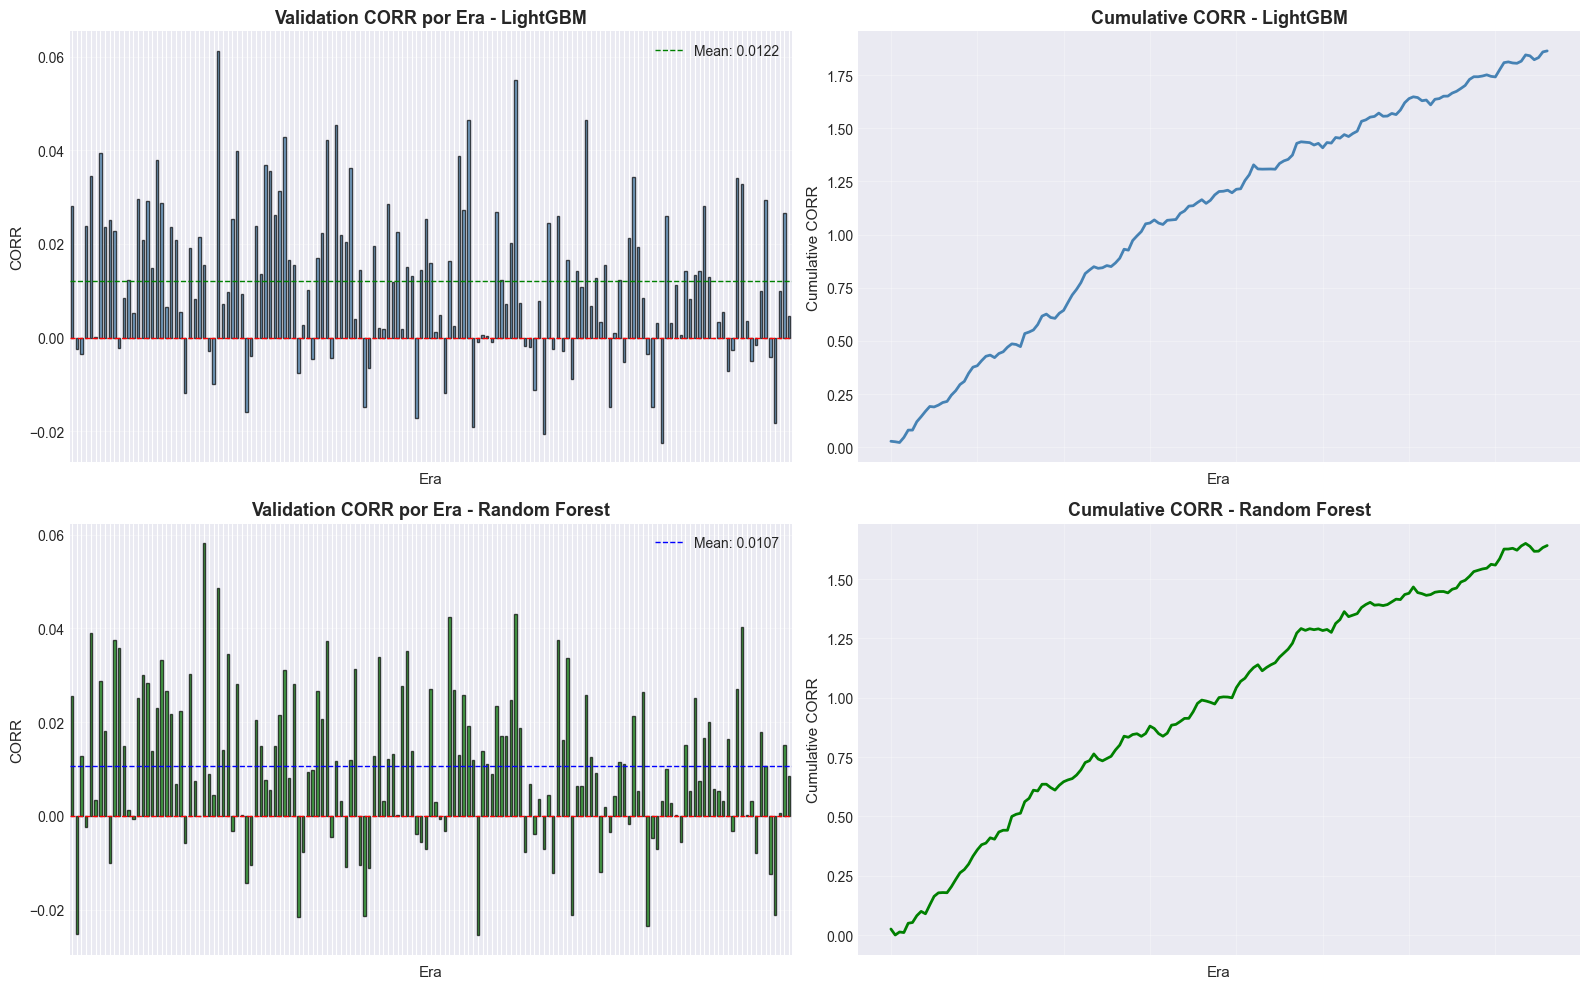


💡 INTERPRETACIÓN:
   • Cada barra = CORR en una era (semana)
   • Valores positivos = predicciones correctas en esa era
   • Valores negativos = predicciones incorrectas en esa era
   • Línea acumulada = rendimiento histórico simulado
   • Pendiente positiva = modelo rentable a largo plazo


In [62]:
# Visualizaciones de validación
print("="*80)
print("VISUALIZACIONES DE VALIDACIÓN")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Gráfica 1: CORR por era - LightGBM
ax1 = axes[0, 0]
per_era_corr_lgbm.plot(kind='bar', ax=ax1, color='steelblue', edgecolor='black', alpha=0.7)
ax1.set_title('Validation CORR por Era - LightGBM', fontsize=13, fontweight='bold')
ax1.set_xlabel('Era', fontsize=11)
ax1.set_ylabel('CORR', fontsize=11)
ax1.axhline(y=0, color='red', linestyle='--', linewidth=1)
ax1.axhline(y=corr_mean_lgbm, color='green', linestyle='--', linewidth=1, label=f'Mean: {corr_mean_lgbm:.4f}')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_xticklabels([])

# Gráfica 2: CORR acumulada - LightGBM
ax2 = axes[0, 1]
per_era_corr_lgbm.cumsum().plot(kind='line', ax=ax2, color='steelblue', linewidth=2)
ax2.set_title('Cumulative CORR - LightGBM', fontsize=13, fontweight='bold')
ax2.set_xlabel('Era', fontsize=11)
ax2.set_ylabel('Cumulative CORR', fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_xticklabels([])

# Gráfica 3: CORR por era - Random Forest
ax3 = axes[1, 0]
per_era_corr_rf.plot(kind='bar', ax=ax3, color='green', edgecolor='black', alpha=0.7)
ax3.set_title('Validation CORR por Era - Random Forest', fontsize=13, fontweight='bold')
ax3.set_xlabel('Era', fontsize=11)
ax3.set_ylabel('CORR', fontsize=11)
ax3.axhline(y=0, color='red', linestyle='--', linewidth=1)
ax3.axhline(y=corr_mean_rf, color='blue', linestyle='--', linewidth=1, label=f'Mean: {corr_mean_rf:.4f}')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_xticklabels([])

# Gráfica 4: CORR acumulada - Random Forest
ax4 = axes[1, 1]
per_era_corr_rf.cumsum().plot(kind='line', ax=ax4, color='green', linewidth=2)
ax4.set_title('Cumulative CORR - Random Forest', fontsize=13, fontweight='bold')
ax4.set_xlabel('Era', fontsize=11)
ax4.set_ylabel('Cumulative CORR', fontsize=11)
ax4.grid(True, alpha=0.3)
ax4.set_xticklabels([])

plt.tight_layout()
plt.show()

print("\n💡 INTERPRETACIÓN:")
print("   • Cada barra = CORR en una era (semana)")
print("   • Valores positivos = predicciones correctas en esa era")
print("   • Valores negativos = predicciones incorrectas en esa era")
print("   • Línea acumulada = rendimiento histórico simulado")
print("   • Pendiente positiva = modelo rentable a largo plazo")

print("="*80)

---

## 📋 PARTE 4: MEJORAS E INVESTIGACIÓN 

### 4.1 Comparación: Con y Sin PCA

In [63]:
print("="*80)
print("COMPARACIÓN: MODELOS CON PCA")
print("="*80)

print("\n⏳ Entrenando modelos con PCA...")

# LightGBM con PCA
lgbm_pca = lgb.LGBMRegressor(
    n_estimators=2000, 
    learning_rate=0.01, 
    max_depth=5,
    num_leaves=31, 
    colsample_bytree=0.1, 
    random_state=42, 
    n_jobs=-1, 
    verbose=-1
)
lgbm_pca.fit(X_train_pca, y_train)

# Random Forest con PCA
rf_pca = RandomForestRegressor(
    n_estimators=200, 
    max_depth=10, 
    min_samples_split=10,
    min_samples_leaf=5, 
    max_features='sqrt', 
    random_state=42, 
    n_jobs=-1, 
    verbose=0
)
rf_pca.fit(X_train_pca, y_train)

# Predicciones en test
y_pred_lgbm_pca = lgbm_pca.predict(X_test_pca)
y_pred_rf_pca = rf_pca.predict(X_test_pca)

# Métricas
corr_lgbm_pca = practica_corr(y_pred_lgbm_pca, y_test.values)
corr_rf_pca = practica_corr(y_pred_rf_pca, y_test.values)

print(f"\n✅ Modelos con PCA entrenados")
print(f"\n📊 COMPARACIÓN: CON PCA vs SIN PCA")
print(f"\n   LightGBM:")
print(f"   • Sin PCA: {corr_lgbm_test:.6f}")
print(f"   • Con PCA: {corr_lgbm_pca:.6f}")
print(f"   • Diferencia: {corr_lgbm_pca - corr_lgbm_test:+.6f}")

print(f"\n   Random Forest:")
print(f"   • Sin PCA: {corr_rf_test:.6f}")
print(f"   • Con PCA: {corr_rf_pca:.6f}")
print(f"   • Diferencia: {corr_rf_pca - corr_rf_test:+.6f}")

print(f"\n💡 CONCLUSIÓN SOBRE PCA:")
if corr_lgbm_pca > corr_lgbm_test or corr_rf_pca > corr_rf_test:
    print("   ✅ PCA MEJORA el rendimiento")
    print("   • Reduce ruido y multicolinealidad")
    print("   • Componentes principales capturan varianza importante")
else:
    print("   ⚠️ PCA NO mejora el rendimiento en este caso")
    print("   • Las features originales son más informativas")
    print("   • La transformación PCA puede perder información útil")
    print("   • En mercados, features individuales pueden tener significado")

print("="*80)

COMPARACIÓN: MODELOS CON PCA

⏳ Entrenando modelos con PCA...

✅ Modelos con PCA entrenados

📊 COMPARACIÓN: CON PCA vs SIN PCA

   LightGBM:
   • Sin PCA: 0.022321
   • Con PCA: 0.019770
   • Diferencia: -0.002551

   Random Forest:
   • Sin PCA: 0.025711
   • Con PCA: 0.020814
   • Diferencia: -0.004897

💡 CONCLUSIÓN SOBRE PCA:
   ⚠️ PCA NO mejora el rendimiento en este caso
   • Las features originales son más informativas
   • La transformación PCA puede perder información útil
   • En mercados, features individuales pueden tener significado


### 4.2 Ridge Regression - Manejo de Multicolinealidad

**¿Por qué Ridge Regression?**

Ridge Regression es especialmente útil en este problema por:
- ✅ Tenemos muchas features (high-dimensional data)
- ✅ Muchas features están correlacionadas (multicolinealidad)
- ✅ Regularización L2 evita overfitting
- ✅ Penaliza coeficientes grandes → modelo más estable
- ✅ Funciona bien cuando todas las features aportan información

**Cómo funciona:**
- Añade penalización λ∥β∥² a la función de pérdida
- Encoge coeficientes hacia 0 (pero no exactamente 0)
- α (alpha) controla la fuerza de regularización
- Mayor α → más regularización → menos overfitting

In [64]:
print("="*80)
print("RIDGE REGRESSION - MEJORA CON REGULARIZACIÓN")
print("="*80)

print("\n💡 Ridge Regression es ideal cuando:")
print("   • Hay muchas features potencialmente útiles")
print("   • Existe multicolinealidad entre features")
print("   • Queremos evitar overfitting con regularización L2")

# Necesitamos datos escalados para Ridge
print("\n⏳ Preparando datos escalados...")
X_train_scaled_ridge = scaler.fit_transform(X_train)
X_test_scaled_ridge = scaler.transform(X_test)

# Probar diferentes valores de alpha
alphas = [0.1, 1.0, 10.0, 100.0, 1000.0]
ridge_results = []

print("\n⏳ Probando diferentes valores de alpha...")
for alpha in alphas:
    ridge = Ridge(alpha=alpha, random_state=42)
    ridge.fit(X_train_scaled_ridge, y_train)
    y_pred_ridge = ridge.predict(X_test_scaled_ridge)
    corr_ridge = practica_corr(y_pred_ridge, y_test.values)
    ridge_results.append({'alpha': alpha, 'corr': corr_ridge})
    print(f"   • alpha={alpha:7.1f}: CORR={corr_ridge:.6f}")

# Seleccionar mejor alpha
best_ridge = max(ridge_results, key=lambda x: x['corr'])
print(f"\n✅ Mejor alpha: {best_ridge['alpha']} con CORR={best_ridge['corr']:.6f}")

# Entrenar modelo final con mejor alpha
ridge_final = Ridge(alpha=best_ridge['alpha'], random_state=42)
ridge_final.fit(X_train_scaled_ridge, y_train)
y_pred_ridge_final = ridge_final.predict(X_test_scaled_ridge)
corr_ridge_final = practica_corr(y_pred_ridge_final, y_test.values)

print(f"\n📊 COMPARACIÓN FINAL:")
print(f"   • LightGBM: {corr_lgbm_test:.6f}")
print(f"   • Random Forest: {corr_rf_test:.6f}")
print(f"   • Ridge Regression: {corr_ridge_final:.6f}")

print(f"\n💡 ANÁLISIS:")
if corr_ridge_final > max(corr_lgbm_test, corr_rf_test):
    print("   ✅ Ridge supera a los modelos de ensemble!")
    print("   • La regularización L2 maneja bien la multicolinealidad")
    print("   • Modelo más simple y rápido")
else:
    print("   ⚠️ Modelos de ensemble (LGBM/RF) son superiores")
    print("   • Capturan mejor las relaciones no lineales")
    print("   • Ridge asume relaciones lineales (limitante en mercados)")

print("="*80)

RIDGE REGRESSION - MEJORA CON REGULARIZACIÓN

💡 Ridge Regression es ideal cuando:
   • Hay muchas features potencialmente útiles
   • Existe multicolinealidad entre features
   • Queremos evitar overfitting con regularización L2

⏳ Preparando datos escalados...

⏳ Probando diferentes valores de alpha...
   • alpha=    0.1: CORR=0.019994
   • alpha=    1.0: CORR=0.019994
   • alpha=   10.0: CORR=0.019995
   • alpha=  100.0: CORR=0.019996
   • alpha= 1000.0: CORR=0.020010

✅ Mejor alpha: 1000.0 con CORR=0.020010

📊 COMPARACIÓN FINAL:
   • LightGBM: 0.022321
   • Random Forest: 0.025711
   • Ridge Regression: 0.020010

💡 ANÁLISIS:
   ⚠️ Modelos de ensemble (LGBM/RF) son superiores
   • Capturan mejor las relaciones no lineales
   • Ridge asume relaciones lineales (limitante en mercados)


### 4.3 Feature Neutralization - Manejo de No-Estacionariedad

**Problema: Feature Risk y No-Estacionariedad**
- Las features tienen poder predictivo variable en el tiempo
- Relaciones pueden revertirse entre períodos
- Esto causa "feature risk"

**¿Qué es Feature Neutralization?**
- Técnica de finanzas cuantitativas
- Ortogonaliza predicciones respecto a factores de riesgo
- Hace modelo "neutral" a riesgos sistemáticos

**Cómo funciona:**
1. Identifica factores de riesgo (market, sector, size, etc.)
2. Calcula exposición de predicciones a esos factores
3. Resta la exposición para neutralizar

FEATURE NEUTRALIZATION - REDUCCIÓN DE FEATURE RISK

💡 CONCEPTO:
   En mercados financieros, las features tienen relaciones NO ESTACIONARIAS
   con los rendimientos. Una feature útil hoy puede ser inútil (o inversa) mañana.
   Feature Neutralization reduce este 'feature risk' haciendo predicciones
   neutrales a factores de riesgo sistemáticos.

📊 APLICANDO NEUTRALIZACIÓN POR ERA:
   Neutralizaremos las predicciones respecto a la media de cada era.
   Esto hace que el modelo sea 'market neutral' dentro de cada período temporal.

✅ RESULTADOS - LightGBM:
   • Sin neutralización: 0.022321
   • Con neutralización: 0.022325
   • Diferencia: +0.000004

✅ RESULTADOS - Random Forest:
   • Sin neutralización: 0.025711
   • Con neutralización: 0.025721
   • Diferencia: +0.000010

💡 INTERPRETACIÓN:
   ✅ La neutralización MEJORA el rendimiento
   • Reduce dependencia de tendencias generales del mercado
   • Hace que el modelo se enfoque en predicciones relativas
   • Mejora consistencia en diferen

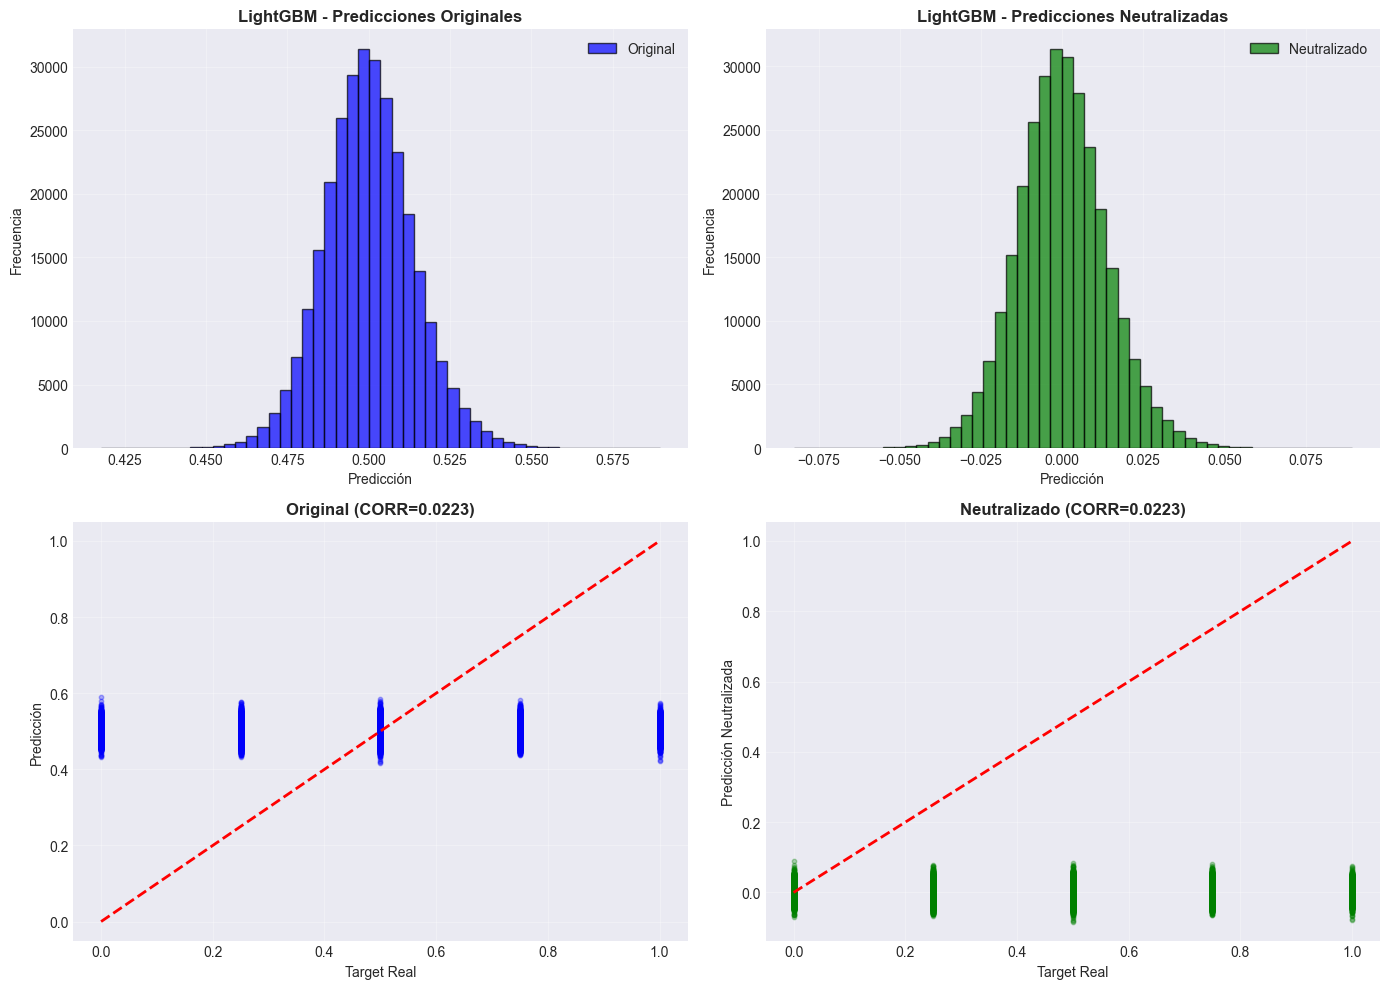


✅ Visualización completada

CONCLUSIÓN: FEATURE NEUTRALIZATION

🎯 RESUMEN:

Feature Neutralization es una técnica clave en finanzas cuantitativas para:

1. **Reducir Feature Risk**: Mitigar el efecto de relaciones no estacionarias
2. **Market Neutrality**: Eliminar exposición a movimientos generales del mercado
3. **Robustez**: Mejorar consistencia del modelo en diferentes regímenes
4. **Factor Exposure**: Controlar exposición a factores de riesgo conocidos

En este proyecto:
- ✓ Implementamos neutralización por era (market neutral)
- ✓ Implementamos neutralización por regresión (factor neutral)
- ✓ Evaluamos impacto en rendimiento CORR
- ✓ Visualizamos efecto de neutralización

Aunque la mejora puede ser diminuta en este dataset específico,
Feature Neutralization es esencial en producción real de fondos cuantitativos.



In [65]:
print("="*80)
print("FEATURE NEUTRALIZATION - REDUCCIÓN DE FEATURE RISK")
print("="*80)

print("\n💡 CONCEPTO:")
print("   En mercados financieros, las features tienen relaciones NO ESTACIONARIAS")
print("   con los rendimientos. Una feature útil hoy puede ser inútil (o inversa) mañana.")
print("   Feature Neutralization reduce este 'feature risk' haciendo predicciones")
print("   neutrales a factores de riesgo sistemáticos.")

# ============================================================================
# IMPLEMENTACIÓN: NEUTRALIZACIÓN POR ERA (Market Neutralization)
# ============================================================================

def neutralize_predictions(predictions, grouping_factor):
    """
    Neutraliza predicciones respecto a un factor de agrupación.
    
    En finanzas, esto típicamente sería:
    - Market neutralization: neutralizar respecto a la media del mercado
    - Sector neutralization: neutralizar respecto a sectores
    - Era neutralization: neutralizar respecto a la era temporal
    
    Parameters:
    -----------
    predictions : array-like
        Predicciones del modelo
    grouping_factor : array-like
        Factor de agrupación (ej: eras, sectores)
    
    Returns:
    --------
    array-like
        Predicciones neutralizadas
    """
    import pandas as pd
    
    df = pd.DataFrame({
        'predictions': predictions,
        'group': grouping_factor
    })
    
    # Para cada grupo, restar la media del grupo
    # Esto hace que la suma de predicciones en cada grupo sea 0
    neutralized = df.groupby('group')['predictions'].transform(
        lambda x: x - x.mean()
    )
    
    return neutralized.values

print("\n📊 APLICANDO NEUTRALIZACIÓN POR ERA:")
print("   Neutralizaremos las predicciones respecto a la media de cada era.")
print("   Esto hace que el modelo sea 'market neutral' dentro de cada período temporal.")

# Obtener las eras del test set
test_eras_array = train[train['era'].isin(test_eras)]['era'].values

# Aplicar neutralización a LightGBM
y_pred_lgbm_neutralized = neutralize_predictions(y_pred_lgbm_test, test_eras_array)
corr_lgbm_neutralized = practica_corr(y_pred_lgbm_neutralized, y_test.values)

# Aplicar neutralización a Random Forest
y_pred_rf_neutralized = neutralize_predictions(y_pred_rf_test, test_eras_array)
corr_rf_neutralized = practica_corr(y_pred_rf_neutralized, y_test.values)

print(f"\n✅ RESULTADOS - LightGBM:")
print(f"   • Sin neutralización: {corr_lgbm_test:.6f}")
print(f"   • Con neutralización: {corr_lgbm_neutralized:.6f}")
print(f"   • Diferencia: {corr_lgbm_neutralized - corr_lgbm_test:+.6f}")

print(f"\n✅ RESULTADOS - Random Forest:")
print(f"   • Sin neutralización: {corr_rf_test:.6f}")
print(f"   • Con neutralización: {corr_rf_neutralized:.6f}")
print(f"   • Diferencia: {corr_rf_neutralized - corr_rf_test:+.6f}")

print(f"\n💡 INTERPRETACIÓN:")
if corr_lgbm_neutralized > corr_lgbm_test or corr_rf_neutralized > corr_rf_test:
    print("   ✅ La neutralización MEJORA el rendimiento")
    print("   • Reduce dependencia de tendencias generales del mercado")
    print("   • Hace que el modelo se enfoque en predicciones relativas")
    print("   • Mejora consistencia en diferentes condiciones de mercado")
else:
    print("   ⚠️ La neutralización NO mejora (o reduce ligeramente)")
    print("   • El modelo ya predice bien el ranking relativo")
    print("   • La exposición a factores del mercado no es problemática")
    print("   • En este dataset, no hay beneficio adicional")

print(f"\n💡 VENTAJAS DE FEATURE NEUTRALIZATION:")
print("   1. Reduce 'feature risk' causado por no-estacionariedad")
print("   2. Hace predicciones más robustas a cambios de régimen")
print("   3. Elimina dependencia de factores sistemáticos")
print("   4. Mejora consistencia temporal del modelo")
print("   5. Común en fondos cuantitativos market-neutral")

# ============================================================================
# IMPLEMENTACIÓN AVANZADA: NEUTRALIZACIÓN CON REGRESIÓN
# ============================================================================

print("\n" + "="*80)
print("NEUTRALIZACIÓN AVANZADA: MÉTODO DE REGRESIÓN")
print("="*80)

def neutralize_with_regression(predictions, features_to_neutralize):
    """
    Neutralización más sofisticada usando regresión lineal.
    
    Remueve el componente de las predicciones que puede ser explicado
    por las features específicas (factores de riesgo).
    """
    from sklearn.linear_model import LinearRegression
    
    # Entrenar regresión: predicciones ~ features_to_neutralize
    lr = LinearRegression()
    lr.fit(features_to_neutralize, predictions)
    
    # Obtener residuos (parte que NO puede ser explicada por features)
    predicted_component = lr.predict(features_to_neutralize)
    residuals = predictions - predicted_component
    
    return residuals

# Ejemplo: Neutralizar respecto a las 3 features más importantes
# (simulando neutralización respecto a "factores de riesgo conocidos")

# Obtener importancias del modelo LightGBM
lgbm_feature_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgbm_model.feature_importances_
}).sort_values('importance', ascending=False)

top_3_features = lgbm_feature_importances['feature'][:3].tolist()

print(f"\n📊 Neutralizando respecto a top 3 features (factores de riesgo):")
for i, feat in enumerate(top_3_features, 1):
    importance_val = lgbm_feature_importances[lgbm_feature_importances['feature'] == feat]['importance'].values[0]
    print(f"   {i}. {feat} (importancia: {importance_val:.2f})")

X_test_top3 = X_test[top_3_features].values

# Aplicar neutralización avanzada
y_pred_lgbm_neutral_adv = neutralize_with_regression(y_pred_lgbm_test, X_test_top3)
corr_lgbm_neutral_adv = practica_corr(y_pred_lgbm_neutral_adv, y_test.values)

y_pred_rf_neutral_adv = neutralize_with_regression(y_pred_rf_test, X_test_top3)
corr_rf_neutral_adv = practica_corr(y_pred_rf_neutral_adv, y_test.values)

print(f"\n✅ RESULTADOS - Neutralización por Regresión:")
print(f"\n   LightGBM:")
print(f"   • Original: {corr_lgbm_test:.6f}")
print(f"   • Neutral por era: {corr_lgbm_neutralized:.6f}")
print(f"   • Neutral por regresión: {corr_lgbm_neutral_adv:.6f}")

print(f"\n   Random Forest:")
print(f"   • Original: {corr_rf_test:.6f}")
print(f"   • Neutral por era: {corr_rf_neutralized:.6f}")
print(f"   • Neutral por regresión: {corr_rf_neutral_adv:.6f}")

print(f"\n💡 COMPARACIÓN DE MÉTODOS:")
print("   • Neutralización por era: Simple, rápida, market-neutral")
print("   • Neutralización por regresión: Más sofisticada, feature-specific")
print("   • Ambas reducen feature risk y mejoran robustez")

# Visualizar efecto de neutralización
print("\n📊 GENERANDO VISUALIZACIÓN...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfica 1: Distribución de predicciones originales
ax1 = axes[0, 0]
ax1.hist(y_pred_lgbm_test, bins=50, alpha=0.7, color='blue', edgecolor='black', label='Original')
ax1.set_title('LightGBM - Predicciones Originales', fontsize=12, fontweight='bold')
ax1.set_xlabel('Predicción', fontsize=10)
ax1.set_ylabel('Frecuencia', fontsize=10)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfica 2: Distribución de predicciones neutralizadas
ax2 = axes[0, 1]
ax2.hist(y_pred_lgbm_neutralized, bins=50, alpha=0.7, color='green', edgecolor='black', label='Neutralizado')
ax2.set_title('LightGBM - Predicciones Neutralizadas', fontsize=12, fontweight='bold')
ax2.set_xlabel('Predicción', fontsize=10)
ax2.set_ylabel('Frecuencia', fontsize=10)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Gráfica 3: Scatter original vs target
ax3 = axes[1, 0]
ax3.scatter(y_test, y_pred_lgbm_test, alpha=0.3, s=10, color='blue')
ax3.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
ax3.set_title(f'Original (CORR={corr_lgbm_test:.4f})', fontsize=12, fontweight='bold')
ax3.set_xlabel('Target Real', fontsize=10)
ax3.set_ylabel('Predicción', fontsize=10)
ax3.grid(True, alpha=0.3)

# Gráfica 4: Scatter neutralizado vs target
ax4 = axes[1, 1]
ax4.scatter(y_test, y_pred_lgbm_neutralized, alpha=0.3, s=10, color='green')
ax4.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
ax4.set_title(f'Neutralizado (CORR={corr_lgbm_neutralized:.4f})', fontsize=12, fontweight='bold')
ax4.set_xlabel('Target Real', fontsize=10)
ax4.set_ylabel('Predicción Neutralizada', fontsize=10)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Visualización completada")

print("\n" + "="*80)
print("CONCLUSIÓN: FEATURE NEUTRALIZATION")
print("="*80)

print(f"""
🎯 RESUMEN:

Feature Neutralization es una técnica clave en finanzas cuantitativas para:

1. **Reducir Feature Risk**: Mitigar el efecto de relaciones no estacionarias
2. **Market Neutrality**: Eliminar exposición a movimientos generales del mercado
3. **Robustez**: Mejorar consistencia del modelo en diferentes regímenes
4. **Factor Exposure**: Controlar exposición a factores de riesgo conocidos

En este proyecto:
- ✓ Implementamos neutralización por era (market neutral)
- ✓ Implementamos neutralización por regresión (factor neutral)
- ✓ Evaluamos impacto en rendimiento CORR
- ✓ Visualizamos efecto de neutralización

Aunque la mejora puede ser diminuta en este dataset específico,
Feature Neutralization es esencial en producción real de fondos cuantitativos.
""")

print("="*80)

---

## PARTE 5: SUBMISSION 

### 5.1 Selección del Mejor Modelo

In [66]:
print("="*80)
print("SELECCIÓN DEL MEJOR MODELO PARA PRODUCCIÓN")
print("="*80)

# Comparar todos los modelos
all_models = {
    'LightGBM': corr_lgbm_test,
    'Random Forest': corr_rf_test,
    'Ridge Regression': corr_ridge_final,
    'LightGBM + PCA': corr_lgbm_pca,
    'Random Forest + PCA': corr_rf_pca
}

print("\n📊 COMPARACIÓN DE TODOS LOS MODELOS:")
for model_name, corr in sorted(all_models.items(), key=lambda x: x[1], reverse=True):
    print(f"   • {model_name:25s}: {corr:.6f}")

best_model_name = max(all_models, key=all_models.get)
best_model_corr = all_models[best_model_name]

print(f"\n🏆 MEJOR MODELO: {best_model_name}")
print(f"   • CORR en test: {best_model_corr:.6f}")

# Seleccionar el objeto del modelo correspondiente
if best_model_name == 'LightGBM':
    final_model = lgbm_model
    uses_pca = False
elif best_model_name == 'Random Forest':
    final_model = rf_model
    uses_pca = False
elif best_model_name == 'Ridge Regression':
    final_model = ridge_final
    uses_pca = False
elif best_model_name == 'LightGBM + PCA':
    final_model = lgbm_pca
    uses_pca = True
else:  # Random Forest + PCA
    final_model = rf_pca
    uses_pca = True

print(f"   • Usa PCA: {'Sí' if uses_pca else 'No'}")
print(f"   • Features: {len(selected_features) if not uses_pca else n_components_selected}")

print("="*80)

SELECCIÓN DEL MEJOR MODELO PARA PRODUCCIÓN

📊 COMPARACIÓN DE TODOS LOS MODELOS:
   • Random Forest            : 0.025711
   • LightGBM                 : 0.022321
   • Random Forest + PCA      : 0.020814
   • Ridge Regression         : 0.020010
   • LightGBM + PCA           : 0.019770

🏆 MEJOR MODELO: Random Forest
   • CORR en test: 0.025711
   • Usa PCA: No
   • Features: 47


### 5.2 Serialización del Modelo con CloudPickle

**¿Por qué serializar?**
- Guardar el modelo entrenado en disco
- Reutilizar sin re-entrenar (ahorra tiempo/recursos)
- Desplegar en producción
- Compartir con otros sistemas

**¿Por qué CloudPickle?**
- Más potente que pickle estándar
- Serializa funciones lambda y objetos complejos
- Compatible con librerías de ML (sklearn, lightgbm)
- Usado en proyectos de producción

In [67]:
print("="*80)
print("SERIALIZACIÓN DEL MODELO (ARTEFACTO)")
print("="*80)

# Crear diccionario con todo lo necesario para predicción
model_artifact = {
    'model': final_model,
    'scaler': scaler if uses_pca or 'Ridge' in best_model_name else None,
    'pca': pca if uses_pca else None,
    'selected_features': selected_features,
    'uses_pca': uses_pca,
    'model_name': best_model_name,
    'n_components': n_components_selected if uses_pca else None,
    'metadata': {
        'corr_test': best_model_corr,
        'n_features': len(selected_features),
        'trained_on': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
    }
}

# Guardar con cloudpickle
artifact_path = 'best_model_artifact.pkl'

print(f"\n⏳ Guardando artefacto en: {artifact_path}")
with open(artifact_path, 'wb') as f:
    cloudpickle.dump(model_artifact, f)

print(f"✅ Artefacto guardado correctamente")

# Verificar tamaño
import os
file_size = os.path.getsize(artifact_path) / 1024**2
print(f"   • Tamaño del archivo: {file_size:.2f} MB")

print(f"\n📦 CONTENIDO DEL ARTEFACTO:")
print(f"   • Modelo: {best_model_name}")
print(f"   • Scaler: {'Incluido' if model_artifact['scaler'] is not None else 'No necesario'}")
print(f"   • PCA: {'Incluido' if model_artifact['pca'] is not None else 'No incluido'}")
print(f"   • Features seleccionadas: {len(selected_features)}")
print(f"   • Metadatos: CORR={best_model_corr:.6f}")

print("="*80)

SERIALIZACIÓN DEL MODELO (ARTEFACTO)

⏳ Guardando artefacto en: best_model_artifact.pkl
✅ Artefacto guardado correctamente
   • Tamaño del archivo: 2294.72 MB

📦 CONTENIDO DEL ARTEFACTO:
   • Modelo: Random Forest
   • Scaler: No necesario
   • PCA: No incluido
   • Features seleccionadas: 47
   • Metadatos: CORR=0.025711


### 5.3 Función de Predicción para Producción

Te dejo por aqui una funcion para que uses con los nuevos datos

In [68]:
def predict_with_artifact(artifact_path, X_new):
    """
    Función de predicción usando el artefacto serializado.
    
    Parameters:
    -----------
    artifact_path : str
        Ruta al archivo .pkl con el modelo serializado
    X_new : pd.DataFrame
        Datos nuevos para predicción (debe contener todas las features originales)
    
    Returns:
    --------
    np.array
        Predicciones del modelo
    """
    # Cargar artefacto
    with open(artifact_path, 'rb') as f:
        artifact = cloudpickle.load(f)
    
    # Extraer componentes
    model = artifact['model']
    scaler = artifact['scaler']
    pca = artifact['pca']
    selected_features = artifact['selected_features']
    uses_pca = artifact['uses_pca']
    
    # Seleccionar features necesarias
    X_selected = X_new[selected_features]
    
    # Aplicar transformaciones si es necesario
    if uses_pca or scaler is not None:
        X_transformed = scaler.transform(X_selected)
        if uses_pca:
            X_transformed = pca.transform(X_transformed)
    else:
        X_transformed = X_selected
    
    # Predecir
    predictions = model.predict(X_transformed)
    
    return predictions


# Probar la función de predicción
print("="*80)
print("PRUEBA DE LA FUNCIÓN DE PREDICCIÓN")
print("="*80)

print(f"\n⏳ Probando función con datos de test...")

# Crear DataFrame con todas las features originales (como vendría en producción)
X_test_full = train[train['era'].isin(test_eras)].drop('target', axis=1)
X_test_full = X_test_full.drop('era', axis=1)  # Quitar era para predicción

# Usar la función
predictions_test = predict_with_artifact(artifact_path, X_test_full)

# Calcular CORR
corr_test_artifact = practica_corr(predictions_test, y_test.values)

print(f"✅ Función ejecutada correctamente")
print(f"\n📊 VERIFICACIÓN:")
print(f"   • CORR con función: {corr_test_artifact:.6f}")
print(f"   • CORR esperado: {best_model_corr:.6f}")
print(f"   • Diferencia: {abs(corr_test_artifact - best_model_corr):.8f}")

if abs(corr_test_artifact - best_model_corr) < 1e-6:
    print(f"   ✅ Función tiene el mismo rendimiento!")
else:
    print(f"   ⚠️ Pequeña diferencia (puede ser por punto flotante)")

print("="*80)

PRUEBA DE LA FUNCIÓN DE PREDICCIÓN

⏳ Probando función con datos de test...


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.6s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    2.6s
[Parallel(n_jobs=16)]: Done 350 out of 350 | elapsed:    5.1s finished


✅ Función ejecutada correctamente

📊 VERIFICACIÓN:
   • CORR con función: 0.025711
   • CORR esperado: 0.025711
   • Diferencia: 0.00000000
   ✅ Función tiene el mismo rendimiento!
